<a href="https://colab.research.google.com/github/FONDECYTACC/cons2025/blob/main/best_subset_based_on_calib_jan26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Best predictors based on calibration, permutation

## 0. Package loading and installation

In [2]:
#@title 🛠️ Professional Workspace Setup { display-mode: "form" }

# 1. Environment Reset & Memory Management
%reset -f
import gc
import re
import time
import numpy as np
import pandas as pd
from google.colab import data_table

# 2. Silent Installations
!pip install -q scikit-survival miceforest xlsxwriter

# 3. Survival Analysis Metrics
from sksurv.metrics import (
    concordance_index_ipcw,
    brier_score,
    integrated_brier_score
)
from sksurv.util import Surv

# 4. HELPER FUNCTIONS (R-Style Utilities)

def glimpse(df, max_width=80):
    """View dataframe structure similar to R's glimpse()"""
    print(f"Rows: {df.shape[0]} | Columns: {df.shape[1]}")
    for col in df.columns:
        dtype = df[col].dtype
        preview = df[col].astype(str).head(5).tolist()
        preview_str = ", ".join(preview)
        if len(preview_str) > max_width:
            preview_str = preview_str[:max_width] + "..."
        print(f"{col:<30} {str(dtype):<15} {preview_str}")

def tabyl(series):
    """Frequency table similar to R's janitor::tabyl()"""
    counts = series.value_counts(dropna=False)
    props = series.value_counts(normalize=True, dropna=False)
    return pd.DataFrame({
        "value": counts.index,
        "n": counts.values,
        "percent": props.values
    }).sort_values("n", ascending=False)

def clean_names(df):
    """Mimic janitor::clean_names for pandas DataFrames."""
    new_cols = []
    for col in df.columns:
        col = col.lower()
        col = re.sub(r"[^\w]+", "_", col)
        col = col.strip("_")
        new_cols.append(col)
    df.columns = new_cols
    return df

# 5. Global Configurations
data_table.enable_dataframe_formatter()
gc.collect()

print("✅ Workspace Reset & Initialized.")
print("📦 Libraries: scikit-survival, miceforest, xlsxwriter loaded.")
print("🔧 Helpers: glimpse(), tabyl(), clean_names() ready.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 43.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.1/222.1 kB 15.3 MB/s eta 0:00:00
✅ Workspace Reset & Initialized.
📦 Libraries: scikit-survival, miceforest, xlsxwriter loaded.
🔧 Helpers: glimpse(), tabyl(), clean_names() ready.


## Format

In [3]:
from google.colab import userdata

# Names of the objects (and secrets)
object_names = [
    "imputations_list_jan26",
    "imputation_nodum_1",
    "X_reduced_imp0",
    "imputation_1"
]
for name in object_names:
    file_id = userdata.get(name)   # secret stored with this key
    if file_id is None:
        raise ValueError(f"No file_id found in userdata for key '{name}'")

    output_file = f"{name}.pkl"
    print(f"Downloading {name} -> {output_file}")
    !gdown {file_id} --output {output_file} --quiet

Load objects in Python

In [4]:
import pandas as pd

# Example: load only imputation 1
imputation_nodum_1 = pd.read_parquet("/content/imputation_nodum_1.pkl")
X_reduced_imp0 = pd.read_parquet("/content/X_reduced_imp0.pkl")
imputation_1 = pd.read_parquet("/content/imputation_1.pkl")


# Quick check
glimpse(imputation_nodum_1)
glimpse(imputation_1)
glimpse(X_reduced_imp0)

Rows: 88504 | Columns: 41
readmit_time_from_adm_m        float64         84.93548387096774, 12.833333333333334, 13.733333333333333, 11.966666666666667, 1...
death_time_from_adm_m          float64         84.93548387096774, 87.16129032258064, 117.2258064516129, 98.93548387096774, 37.9...
adm_age_rec3                   float64         31.53, 20.61, 42.52, 60.61, 45.08
porc_pobr                      float64         0.175679117441177, 0.187835901975632, 0.130412444472313, 0.133759185671806, 0.08...
dit_m                          float64         15.967741935483872, 5.833333333333334, 0.4752688172043005, 6.966666666666667, 6....
sex_rec                        category        man, man, man, woman, man
tenure_status_household        category        stays temporarily with a relative, owner/transferred dwellings/pays dividends, s...
cohabitation                   category        alone, family of origin, with couple/children, with couple/children, family of o...
sub_dep_icd10_status           cat

In [5]:
import pickle
import pandas as pd
import numpy as np

file_path = '/content/imputations_list_jan26.pkl'

with open(file_path, 'rb') as f:
    imputations_list_jan26 = pickle.load(f)

print(f"Successfully loaded '{file_path}'\n")
print(f"Type of loaded object: {type(imputations_list_jan26)}")

if isinstance(imputations_list_jan26, list) and len(imputations_list_jan26) > 0:
    print("First element type:", type(imputations_list_jan26[0]))
    if isinstance(imputations_list_jan26[0], dict):
        print("First element keys:", imputations_list_jan26[0].keys())
    elif isinstance(imputations_list_jan26[0], (pd.DataFrame, np.ndarray)):
        print("First element shape:", imputations_list_jan26[0].shape)

Successfully loaded '/content/imputations_list_jan26.pkl'

Type of loaded object: <class 'list'>
First element type: <class 'pandas.core.frame.DataFrame'>
First element shape: (88504, 56)


This code block:

1.  **Imports the `pickle` library**: This library implements binary protocols for serializing and de-serializing a Python object structure.
2.  **Specifies the `file_path`**: It points to the `.pkl` file you selected.
3.  **Opens the file in binary read mode (`'rb'`)**: This is necessary for loading pickle files.
4.  **Loads the object**: `pickle.load(f)` reads the serialized object from the file and reconstructs it in memory.
5.  **Prints confirmation and basic information**: It verifies that the file was loaded and shows the type of the loaded object, and some details about the first element if it's a list containing common data structures.

#### Compare databases (transformed and original)

Inspect and compare the column names of two datasets: the first imputation from imputations_list_jan26 (which likely contains dummy variables) and imputation_nodum_1 (which, as its name suggests, probably doesn't have dummy variables).


In [6]:
# Inspect columns of the first imputation
cols_first_imp = imputations_list_jan26[0].columns.tolist()
print("First imputation columns:", cols_first_imp[:10], "... total:", len(cols_first_imp))

# Inspect columns of imputation_no_dum
cols_nodum = imputation_nodum_1.columns.tolist()
print("No-dum columns:", cols_nodum[:10], "... total:", len(cols_nodum))

# Compare overlap
common_cols = set(cols_first_imp).intersection(cols_nodum)
missing_in_imp = [c for c in cols_nodum if c not in cols_first_imp]
missing_in_nodum = [c for c in cols_first_imp if c not in cols_nodum]

print("Common columns:", len(common_cols))
print("Missing in imputations_list_jan26:", missing_in_imp)

First imputation columns: ['adm_age_rec3', 'porc_pobr', 'dit_m', 'tenure_status_household', 'prim_sub_freq_rec', 'national_foreign', 'urbanicity_cat', 'ed_attainment_corr', 'evaluacindelprocesoteraputico', 'eva_consumo'] ... total: 56
No-dum columns: ['readmit_time_from_adm_m', 'death_time_from_adm_m', 'adm_age_rec3', 'porc_pobr', 'dit_m', 'sex_rec', 'tenure_status_household', 'cohabitation', 'sub_dep_icd10_status', 'any_violence'] ... total: 41
Common columns: 24
Missing in imputations_list_jan26: ['readmit_time_from_adm_m', 'death_time_from_adm_m', 'sex_rec', 'cohabitation', 'sub_dep_icd10_status', 'any_violence', 'tr_outcome', 'adm_motive', 'first_sub_used', 'primary_sub_mod', 'tipo_de_vivienda_rec2', 'plan_type_corr', 'occupation_condition_corr24', 'marital_status_rec', 'readmit_event', 'death_event', 'center_id']


In [7]:
# Inspect columns of the first imputation
cols_first_imp_raw = imputation_1.columns.tolist()
print("First imputation columns:", cols_first_imp_raw[:10], "... total:", len(cols_first_imp_raw))

# Compare overlap
common_cols_raw = set(cols_first_imp_raw).intersection(cols_nodum)
missing_in_imp_raw = [c for c in cols_nodum if c not in cols_first_imp_raw]

print("Common columns:", len(common_cols_raw))
print("Missing in imputations_list_jan26:", missing_in_imp_raw)
print(common_cols_raw)

First imputation columns: ['readmit_time_from_adm_m', 'death_time_from_adm_m', 'adm_age_rec3', 'porc_pobr', 'dit_m', 'national_foreign', 'ethnicity', 'dg_psiq_cie_10_instudy', 'dg_psiq_cie_10_dg', 'dx_f3_mood'] ... total: 78
Common columns: 16
Missing in imputations_list_jan26: ['sex_rec', 'tenure_status_household', 'cohabitation', 'sub_dep_icd10_status', 'any_violence', 'prim_sub_freq_rec', 'tr_outcome', 'adm_motive', 'first_sub_used', 'primary_sub_mod', 'tipo_de_vivienda_rec2', 'plan_type_corr', 'occupation_condition_corr24', 'marital_status_rec', 'urbanicity_cat', 'ed_attainment_corr', 'evaluacindelprocesoteraputico', 'eva_consumo', 'eva_fam', 'eva_relinterp', 'eva_ocupacion', 'eva_sm', 'eva_fisica', 'eva_transgnorma', 'center_id']
{'dg_psiq_cie_10_instudy', 'dx_f_any_severe_mental', 'readmit_event', 'dx_f6_personality', 'dx_f3_mood', 'dit_m', 'death_time_from_adm_m', 'national_foreign', 'death_event', 'any_phys_dx', 'readmit_time_from_adm_m', 'adm_age_rec3', 'ethnicity', 'polysubst

In [8]:
import pandas as pd

# Example: choose a combination of variables that uniquely identify rows
key_vars = ["adm_age_rec3", "porc_pobr", "dit_m"]

# Take one imputation (first element of the list) and merge with the no-dum dataset
df_imp = imputations_list_jan26[0]
df_nodum = imputation_nodum_1

merged_check = pd.merge(
    df_imp[key_vars],
    df_nodum[key_vars],
    on=key_vars,
    how="inner"
)

print(f"Merged rows: {merged_check.shape[0]}")
print("Preview of merged check:")
print(merged_check.head())

#drop merge
del merged_check

Merged rows: 88516
Preview of merged check:
   adm_age_rec3  porc_pobr      dit_m
0         31.53   0.175679  15.967742
1         20.61   0.187836   5.833333
2         42.52   0.130412   0.475269
3         60.61   0.133759   6.966667
4         45.08   0.083189   6.903226


In [9]:
import pandas as pd

# Example: choose a combination of variables that uniquely identify rows
key_vars_raw = ['dit_m',
            'readmit_time_from_adm_m',
            'death_time_from_adm_m',
            'adm_age_rec3']
# Take one imputation (first element of the list) and merge with the no-dum dataset
df_raw = imputation_1

merged_check_raw = pd.merge(
    df_imp[key_vars],
    df_raw[key_vars],
    on=key_vars,
    how="inner"
)

print(f"Merged rows: {merged_check_raw.shape[0]}")
print("Preview of merged check:")
print(merged_check_raw.head())
print(f"{(merged_check_raw.shape[0] / imputation_1.shape[0] * 100):.2f}%")
#drop merge
del merged_check_raw

Merged rows: 88516
Preview of merged check:
   adm_age_rec3  porc_pobr      dit_m
0         31.53   0.175679  15.967742
1         20.61   0.187836   5.833333
2         42.52   0.130412   0.475269
3         60.61   0.133759   6.966667
4         45.08   0.083189   6.903226
100.01%


### Create bins for followup (landmarks)

This code prepares your data for survival analysis. It extracts the time until an event (like readmission or death) and whether that event actually happened for each patient from the df_nodum dataset. Then, it automatically creates a set of important time points, called an 'evaluation grid', which are specific moments to assess the model's performance on both readmission and death outcomes.


In [10]:
import numpy as np

# Required columns for survival outcomes
required = ["readmit_time_from_disch_m", "readmit_event",
            "death_time_from_disch_m", "death_event"]

# Check that df_raw has all required columns
missing = [c for c in required if c not in df_raw.columns]
if missing:
    raise KeyError(f"df_nodum is missing columns: {missing}")

# Create time/event arrays directly from df_raw
time_readm = df_raw["readmit_time_from_adm_m"].to_numpy()
event_readm = (df_raw["readmit_event"].to_numpy() == 1)

time_death = df_raw["death_time_from_adm_m"].to_numpy()
event_death = (df_nodum["death_event"].to_numpy() == 1)

print("Arrays created for df_raw:")
print("Readmission times:", time_readm[:5])
print("Readmission events:", event_readm[:5])
print("Death times:", time_death[:5])
print("Death events:", event_death[:5])

# Build evaluation grids (quantiles of event times)
event_times_readm = time_readm[event_readm]
event_times_death = time_death[event_death]

if len(event_times_readm) < 5 or len(event_times_death) < 5:
    raise ValueError("Too few events in df_raw to build reliable time grids.")

times_eval_readm = np.unique(np.quantile(event_times_readm, np.linspace(0.05, 0.95, 50)))
times_eval_death = np.unique(np.quantile(event_times_death, np.linspace(0.05, 0.95, 50)))

print("Eval times (readmission):", times_eval_readm[:5], "...", times_eval_readm[-5:])
print("Eval times (death):", times_eval_death[:5], "...", times_eval_death[-5:])


Arrays created for df_raw:
Readmission times: [84.93548387 12.83333333 13.73333333 11.96666667 14.25806452]
Readmission events: [False  True  True  True  True]
Death times: [ 84.93548387  87.16129032 117.22580645  98.93548387  37.93548387]
Death events: [False False False False False]
Eval times (readmission): [3.93548387 4.77419355 5.45058701 6.06492649 6.67741935] ... [54.44173469 58.41566162 63.23333333 68.54767171 74.68983871]
Eval times (death): [4.16290323 5.43022383 6.68564845 8.24254115 9.77961817] ... [81.92700461 85.41186103 88.78518762 93.5538183  99.21935484]


# 3. “Best predictors” (variable importance) based on calibration

To identify predictors that most influenced overall prediction error (calibration and discrimination combined), we computed permutation importance using the Integrated Brier Score (IBS). Within each imputed dataset, we ran k-fold cross-validation and fitted Coxnet models in the training folds. For each fold, we first obtained the out-of-sample IBS using the test data. We then permuted one predictor at a time in the test set, recomputed survival predictions and the IBS, and recorded the increase in IBS (worsening of prediction error). These IBS increases were pooled across folds and imputations, so that `mean_increase_ibs` summarized how much each predictor worsened out-of-sample IBS on average, while respecting both multiple imputation and cross-validation. Sorting predictors by `mean_increase_ibs` and selecting the top 20 yielded the most influential predictors from the standpoint of overall calibration-weighted predictive accuracy.

It fits a Coxnet model (a penalized Cox proportional hazards model from the sksurv library) and measures how much each feature impacts the model's performance, specifically using the Integrated Brier Score (IBS) as the metric. IBS is a measure of prediction error in survival models—lower is better, so permuting (randomly shuffling) a feature and seeing how much IBS increases indicates that feature's importance.

The function runs CV across folds and imputations, fits the model, computes a baseline IBS, then repeatedly permutes each feature's values in the test set to see the "drop" (increase) in IBS. It aggregates these across all runs to rank features by their mean IBS increase (higher increase = more important feature).

First, we eliminated inmortal time bias (dead patients look like without readmission).

This correction is essentially the Cause-Specific Hazard preparation. It is the correct way to handle Aim 3 unless you switch to a Fine-Gray model (which treats death as a specific type of event 2, rather than censoring 0). For RSF/Coxnet, censoring 0 is the correct approach.

In [11]:
import numpy as np

# Step 1. Extract survival outcomes directly from df_raw
time_readm = df_raw["readmit_time_from_adm_m"].to_numpy()
event_readm = (df_raw["readmit_event"].to_numpy() == 1)

time_death = df_raw["death_time_from_adm_m"].to_numpy()
event_death = (df_raw["death_event"].to_numpy() == 1)

# Step 2. Build structured arrays (Surv objects)
y_surv_readm = np.empty(len(time_readm), dtype=[("event", "?"), ("time", "<f8")])
y_surv_readm["event"] = event_readm
y_surv_readm["time"] = time_readm

y_surv_death = np.empty(len(time_death), dtype=[("event", "?"), ("time", "<f8")])
y_surv_death["event"] = event_death
y_surv_death["time"] = time_death

# Step 3. Replicate across imputations
n_imputations = len(imputations_list_jan26)
y_surv_readm_list = [y_surv_readm for _ in range(n_imputations)]
y_surv_death_list = [y_surv_death for _ in range(n_imputations)]

import numpy as np

def correct_competing_risks(X_list, y_readm_list, y_death_list):
    """
    Adjust survival outcomes for competing risks (death vs. readmission).

    Parameters
    ----------
    X_list : list of pd.DataFrame
        Imputed predictor datasets (same rows across imputations).
    y_readm_list : list of structured arrays
        Surv(event, time) arrays for readmission.
    y_death_list : list of structured arrays
        Surv(event, time) arrays for death.

    Returns
    -------
    y_readm_corrected_list : list of structured arrays
        Corrected readmission outcomes (death treated as censoring).
    """
    corrected = []
    for y_readm, y_death in zip(y_readm_list, y_death_list):
        y_corr = y_readm.copy()
        # If patient died before readmission → censor at death time
        for i in range(len(y_corr)):
            if y_death["event"][i] and y_death["time"][i] < y_corr["time"][i]:
                y_corr["event"][i] = False
                y_corr["time"][i] = y_death["time"][i]
        corrected.append(y_corr)
    return corrected


# Step 4. Apply correction
y_surv_readm_list_corrected = correct_competing_risks(
    imputations_list_jan26,
    y_surv_readm_list,
    y_surv_death_list
)


In [ ]:
# Check type and length
type(y_surv_readm_list_corrected), len(y_surv_readm_list_corrected)

# Look at the first element
y_surv_readm_list_corrected[0][:5]   # first 5 rows


array([(False, 84.93548387), ( True, 12.83333333), ( True, 13.73333333),
       ( True, 11.96666667), ( True, 14.25806452)],
      dtype=[('event', '?'), ('time', '<f8')])

In [ ]:
#@title 📥 Export IBS Importance Results { display-mode: "form" }
#@markdown Run this after your IBS-based permutation importance is finished.

import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sksurv.metrics import brier_score, integrated_brier_score
from joblib import Parallel, delayed
from google.colab import files, data_table
import pandas as pd

def permutation_importance_ibs_cv_mi2(
    X_list,
    y_surv_list, # Renamed to y_surv_list to reflect it's a list of outcomes
    times_eval,
    alpha_idx=25,
    n_splits=5,
    n_repeats=3,
    random_state=2125,
    l1_ratio=0.9,
    alpha_min_ratio=0.01,
    n_alphas=50,
    max_iter=100000,
    n_jobs=-1,
):
    """
    Highly optimized version using risk scores and coefficient-based updates.

    Parameters
    ----------
    X_list : list of pandas.DataFrame
        List of imputed datasets (same samples, different imputations)
    y_surv_list : list of structured array
        List of survival outcomes (time, event), one for each imputed dataset
    times_eval : array-like
        Time points for evaluation
    alpha_idx : int
        Index of alpha to use from regularization path
    n_splits : int
        Number of CV folds
    n_repeats : int
        Number of permutation repeats per feature
    random_state : int
        Random seed for reproducibility
    l1_ratio : float
        ElasticNet mixing parameter (0 <= l1_ratio <= 1)
    alpha_min_ratio : float
        Minimum alpha as fraction of maximum alpha
    n_alphas : int
        Number of alphas along regularization path
    max_iter : int
        Maximum iterations for model fitting
    n_jobs : int
        Number of parallel jobs (-1 for all cores)

    Returns
    -------
    baseline_ibs_mean : float
        Mean baseline IBS across folds and imputations
    baseline_ibs_sd : float
        Standard deviation of baseline IBS
    df_imp_ibs : pandas.DataFrame
        Dataframe with permutation importance results
    """
    # Convert to NumPy arrays upfront
    feature_names = X_list[0].columns.tolist()
    n_features = len(feature_names)
    X_list = [X.values.astype(np.float64, copy=False) for X in X_list]
    times_eval = np.asarray(times_eval, dtype=np.float64)
    n_imputations = len(X_list)

    # Precompute CV splits once
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    cv_splits = list(kf.split(np.arange(X_list[0].shape[0])))

    def compute_fold_optimized(d, fold_idx, train_idx, test_idx):
        """
        Optimized fold computation using coefficient-based risk updates.
        """
        X_imp = X_list[d]
        y_imp = y_surv_list[d] # Get the y for *this* imputation

        X_train = X_imp[train_idx]
        X_test = X_imp[test_idx]
        y_train = y_imp[train_idx] # Slice the y for this imputation
        y_test = y_imp[test_idx]   # Slice the y for this imputation

        local_rng = np.random.RandomState(random_state + d * n_splits + fold_idx)

        # Fit Coxnet
        model = CoxnetSurvivalAnalysis(
            l1_ratio=l1_ratio,
            alpha_min_ratio=alpha_min_ratio,
            n_alphas=n_alphas,
            normalize=False,
            fit_baseline_model=True,
            max_iter=max_iter,
            verbose=False,
        )
        model.fit(X_train, y_train)

        # Handle alpha selection safely
        eff_alpha_idx = min(alpha_idx, len(model.alphas_) - 1)
        alpha_val = model.alphas_[eff_alpha_idx]

        # Extract coefficients for risk score computation
        coef = model.coef_[:, eff_alpha_idx]

        # Access baseline survival
        baseline_estimator = model._baseline_models[eff_alpha_idx]
        S0 = baseline_estimator.baseline_survival_(times_eval)

        # Precompute baseline risk scores
        baseline_risks = model.predict(X_test, alpha=alpha_val)

        # Compute baseline survival probabilities
        S_test = np.power(S0[None, :], np.exp(baseline_risks[:, None]))

        # Get effective time grid for Brier score
        times_brier, _ = brier_score(
            survival_train=y_train,
            survival_test=y_test,
            estimate=S_test,
            times=times_eval,
        )
        n_times = len(times_brier)
        S_test_valid = S_test[:, :n_times]

        # Baseline IBS
        ibs_base = integrated_brier_score(
            survival_train=y_train,
            survival_test=y_test,
            estimate=S_test_valid,
            times=times_brier,
        )

        # Optimized permutation importance using risk score updates
        fold_drops = np.zeros((n_features, n_repeats))

        for col_idx in range(n_features):
            col_original = X_test[:, col_idx].copy()
            coef_col = coef[col_idx]

            for r in range(n_repeats):
                # Generate permutation
                permuted_values = local_rng.permutation(col_original)

                # Fast risk score update instead of full prediction
                risk_delta = (permuted_values - col_original) * coef_col
                risks_perm = baseline_risks + risk_delta

                # Compute survival probabilities from updated risks
                S_perm = np.power(S0[None, :], np.exp(risks_perm[:, None]))
                S_perm_valid = S_perm[:, :n_times]

                # Compute IBS for permuted feature
                ibs_perm = integrated_brier_score(
                    survival_train=y_train,
                    survival_test=y_test,
                    estimate=S_perm_valid,
                    times=times_brier,
                )
                fold_drops[col_idx, r] = ibs_perm - ibs_base

        return ibs_base, fold_drops

    print(f"\n=== {n_imputations} imputations – {n_splits}-fold CV permutation importance (IBS) ===")
    print(f"Total iterations: {n_imputations * n_splits}")
    print(f"Features: {n_features}, Permutation repeats: {n_repeats}")

    # Parallel execution
    results = Parallel(n_jobs=n_jobs, backend='loky', verbose=10)(
        delayed(compute_fold_optimized)(d, fold_idx, train_idx, test_idx)
        for d in range(n_imputations)
        for fold_idx, (train_idx, test_idx) in enumerate(cv_splits)
    )

    # Aggregate results
    baseline_ibs_list = [res[0] for res in results]

    # Concatenate all permutation results
    all_drops = np.concatenate([res[1] for res in results], axis=1)

    # Create results dataframe
    df_imp_ibs = pd.DataFrame({
        "feature": feature_names,
        "mean_increase_ibs": all_drops.mean(axis=1),
        "sd_increase_ibs": all_drops.std(axis=1, ddof=1),
        "n_evals": all_drops.shape[1],
    }).sort_values("mean_increase_ibs", ascending=False).reset_index(drop=True)

    # Baseline IBS statistics
    baseline_ibs_mean = np.mean(baseline_ibs_list)
    baseline_ibs_sd = np.std(baseline_ibs_list, ddof=1) if len(baseline_ibs_list) > 1 else 0.0

    print("\n=== Baseline CV IBS over imputations & folds ===")
    print(f"Mean \u00B1 SD: {baseline_ibs_mean:.4f} \u00B1 {baseline_ibs_sd:.4f}")
    print(f"Range: [{np.min(baseline_ibs_list):.4f}, {np.max(baseline_ibs_list):.4f}]")

    # 1. Format and Display the Table
    print("📊 Top 20 Features: Integrated Brier Score (IBS) Importance")
    data_table.enable_dataframe_formatter()
    styled_df = df_imp_ibs.head(20).style.background_gradient(subset=['mean_increase_ibs'], cmap='YlOrRd')
    display(styled_df)

    # 2. Export to Excel
    filename = "IBS_Importance_Results.xlsx"
    df_imp_ibs.to_excel(filename, index=False)
    files.download(filename)

    print(f"✅ Excel file '{filename}' downloaded.")
    print(f"✅ Process completed.")
    return baseline_ibs_mean, baseline_ibs_sd, df_imp_ibs

### Execute
- **`X_list`** (set to `X_reduced_list` in your code): This is a list of Pandas DataFrames. The function loops over each imputation separately during CV, fitting models and computing importances for robustness.

- **`y_surv`** (set to `y_surv_readm`): This is your survival outcome/target variable, as a NumPy structured array with two fields: 'event' (bool: True if event like death/readmission occurred, False if censored) and 'time' (float: time to event or censoring).

- **`times_eval`** (set to `times_eval_readm`): This is a NumPy array or list of evenly spaced time points covering your data's range. More points = finer evaluation but slightly higher computation. Too few = coarse/less accurate IBS.

- **`alpha_idx`** (set to 25, default=25): This is the index in the Coxnet model's alpha path (regularization strengths) to use for predictions and importance. Selects the effective alpha for the model after fitting (e.g., index 0 is strongest regularization, higher indices are weaker). Typical values range 0-50. Lower index = more regularization (a sparser model with fewer features used); Higher = less regularization (more complex model). Tune via separate CV if needed.

- **`n_splits`** (set to 5, default=5):  This is the number of folds in K-Fold CV.  Splits data into train/test sets repeatedly (e.g., 5 folds = 80% train, 20% test per fold). Precomputed once and reused across imputations.  Balances bias-variance; 5 is a good default for moderate datasets.

- **`n_repeats`** (set to 5, default=3): This is the number of times to repeat the permutation for each feature in each fold/imputation. For each feature, shuffles its test-set values `n_repeats` times, recomputes IBS each time, and averages the drops for stability. Increase for better precision and more reliable importance scores (lower SD in output DF), but runtime increases linearly (e.g., doubles if going from 3 to 6).

### Default Arguments (Not Specified in Your Call, So They Use These Values)
These are less commonly changed but control the underlying Coxnet model and computation:
- `random_state=2125`: Seed for CV splitting and permutations (ensures reproducibility).
- `l1_ratio=0.1`: Elastic net mixing (0.1 = mostly L2/Ridge vs. L1/Lasso for feature selection).
- `alpha_min_ratio=0.01`: Smallest alpha as a fraction of the max (controls regularization range).
- `max_iter=100000`: Max iterations for model convergence (high to avoid early stopping).
- `n_jobs=-1`: Parallel jobs (uses all CPU cores for speed via Joblib).

As of 2026-01-20, we kept the less aggressive model

In [ ]:
import time
# Start timer
start_time = time.time()

baseline_ibs_readm, baseline_ibs_sd_readm, df_imp_ibs_readm = (
    permutation_importance_ibs_cv_mi2(
        X_list=imputations_list_jan26,
        y_surv_list=y_surv_readm_list_corrected,
        times_eval=times_eval_readm,
        alpha_idx=49,   # same index you’ve been using
        n_splits=5,
        n_repeats=50,     # you can increase to 5 if runtime is acceptable
        # More flexible regularization:
        l1_ratio=0.1,             # ← BALANCED Lasso/Ridge (was 0.9): 50% Lasso + 50% Ridge keeps more features active
        alpha_min_ratio=0.01,      # ← LESS aggressive alpha range (was 0.01):  Focuses on less regularized models
        n_alphas=50,
        max_iter=100000,
        n_jobs=-1
    )
)
#[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed: 67.9min finished

# End timer
end_time = time.time() # Print elapsed time in seconds
elapsed = end_time - start_time
print(f"Process completed in {elapsed/60:.2f} minutes")



=== 5 imputations – 5-fold CV permutation importance (IBS) ===
Total iterations: 25
Features: 56, Permutation repeats: 50


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed: 10.7min
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed: 21.4min
[Parallel(n_jobs=-1)]: Done  13 out of  25 | elapsed: 21.9min remaining: 20.2min
[Parallel(n_jobs=-1)]: Done  16 out of  25 | elapsed: 21.9min remaining: 12.3min
[Parallel(n_jobs=-1)]: Done  19 out of  25 | elapsed: 32.4min remaining: 10.2min
[Parallel(n_jobs=-1)]: Done  22 out of  25 | elapsed: 32.7min remaining:  4.5min
[Parallel(n_jobs=-1)]: Done  25 out of  25 | elapsed: 38.0min finished



=== Baseline CV IBS over imputations & folds ===
Mean ± SD: 0.1340 ± 0.0016
Range: [0.1322, 0.1360]
📊 Top 20 Features: Integrated Brier Score (IBS) Importance


,feature,mean_increase_ibs,sd_increase_ibs,n_evals
0,dit_m,0.000539,0.000095,1250
1,sex_rec_woman,0.000510,0.000080,1250
2,adm_age_rec3,0.000383,0.000133,1250
3,plan_type_corr_m_pr,0.000227,0.000027,1250
4,plan_type_corr_pg_pr,0.000155,0.000042,1250
5,ethnicity,0.000139,0.000024,1250
6,dg_psiq_cie_10_dg,0.000118,0.000028,1250
7,primary_sub_mod_alcohol,0.000108,0.000040,1250
8,prim_sub_freq_rec,0.000108,0.000032,1250
9,sub_dep_icd10_status_drug_dependence,0.000077,0.000027,1250


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Excel file 'IBS_Importance_Results.xlsx' downloaded.
✅ Process completed.
Process completed in 2280.14 seconds


In [ ]:
# Start timer
start_time = time.time()

baseline_ibs_death, baseline_ibs_sd_death, df_imp_ibs_death = (
    permutation_importance_ibs_cv_mi2(
        X_list=imputations_list_jan26,
        y_surv_list=y_surv_death_list, # Changed from y_surv=y_surv_death
        times_eval=times_eval_death,
        alpha_idx=49,
        n_splits=10,
        n_repeats=50,
        # More flexible regularization:
        l1_ratio=0.1,             # ← BALANCED Lasso/Ridge (was 0.9): 50% Lasso + 50% Ridge keeps more features active
        alpha_min_ratio=0.01,      # ← LESS aggressive alpha range (was 0.01):  Focuses on less regularized models
        n_alphas=50,
        max_iter=100000,
        n_jobs=-1
    )
)

# End timer
end_time = time.time() # Print elapsed time in seconds
elapsed = end_time - start_time
print(f"Process completed in {elapsed/60:.2f} minutes")


=== 5 imputations – 10-fold CV permutation importance (IBS) ===
Total iterations: 50
Features: 56, Permutation repeats: 50


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:  8.7min
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed: 17.3min
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed: 18.4min
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed: 34.4min
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed: 43.4min
[Parallel(n_jobs=-1)]: Done  41 out of  50 | elapsed: 51.6min remaining: 11.3min
[Parallel(n_jobs=-1)]: Done  47 out of  50 | elapsed: 53.8min remaining:  3.4min



=== Baseline CV IBS over imputations & folds ===
Mean ± SD: 0.0319 ± 0.0010
Range: [0.0298, 0.0338]
📊 Top 20 Features: Integrated Brier Score (IBS) Importance


[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed: 57.2min finished


,feature,mean_increase_ibs,sd_increase_ibs,n_evals
0,adm_age_rec3,0.002701,0.000236,2500
1,primary_sub_mod_alcohol,0.000090,0.000017,2500
2,dit_m,0.000066,0.000040,2500
3,eva_ocupacion,0.000044,0.000024,2500
4,eva_fisica,0.000040,0.000019,2500
5,prim_sub_freq_rec,0.000031,0.000013,2500
6,tenure_status_household,0.000016,0.000016,2500
7,cohabitation_with_couple_children,0.000010,0.000004,2500
8,eva_sm,0.000006,0.000005,2500
9,evaluacindelprocesoteraputico,0.000003,0.000003,2500


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Excel file 'IBS_Importance_Results.xlsx' downloaded.
✅ Process completed.
Process completed in 3436.51 seconds


# Landmark

We performed a **regularized Cox regression (Coxnet)** analysis utilizing a dual-validation framework: **Multiple Imputation** to handle missing data and **-fold Cross-Validation** to ensure model stability.

* **Discrimination:** Measured via **Time-dependent AUC** and **C-index** to assess how well the model separates risk groups over time.
* **Calibration:** Evaluated using the **Brier Score (BS)** at specific intervals and the **Integrated Brier Score (IBS)** to verify the accuracy of predicted probabilities.
* **Importance:** Ranked features via **Permutation Importance**, quantifying the decrease in model accuracy (IBS increase) when each variable is randomized.

In [ ]:
#@title 🛠️ Calibration Analysis & Calibration Plotting Functions { display-mode: "form" }
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sksurv.metrics import brier_score, integrated_brier_score
from joblib import Parallel, delayed

def permutation_importance_calibration_timespecific_cv_mi(
    X_list,
    y_surv_list,
    times_eval,
    alpha_idx=25,
    n_splits=5,
    n_repeats=3,
    random_state=2125,
    l1_ratio=0.1,
    alpha_min_ratio=0.001,
    n_alphas=50,
    max_iter=100000,
    n_jobs=-1,
):
    """
    Multiple-imputation + k-fold CV permutation importance for Coxnet
    with time-specific CALIBRATION metrics (Brier Score).

    Parameters
    ----------
    X_list : list of pandas.DataFrame
        List of imputed design matrices (one per imputation).
    y_surv_list : list of structured arrays
        List of Surv(event, time) structured arrays (one per imputation).
    times_eval : array-like
        Time points at which to evaluate calibration.
    alpha_idx : int
        Index along the Coxnet regularization path to use for predictions.
    n_splits : int
        Number of CV folds.
    n_repeats : int
        Number of permutations per feature per fold.
    random_state : int
        Seed for KFold and permutations.
    l1_ratio : float
        ElasticNet mixing parameter.
    alpha_min_ratio : float
        Minimum alpha as fraction of maximum alpha.
    n_alphas : int
        Number of alphas along regularization path.
    max_iter : int
        Maximum iterations for model fitting.
    n_jobs : int
        Number of parallel jobs (-1 = all cores).

    Returns
    -------
    df_global_metrics : pandas.DataFrame
        Global calibration metrics (IBS).
    df_time_metrics : pandas.DataFrame
        Time-specific calibration metrics (BS(t)) for each time point.
    df_importance : pandas.DataFrame
        Feature-level permutation importance (IBS-based).
    """
    # Convert to NumPy arrays upfront for speed
    feature_names = X_list[0].columns.tolist()
    n_features = len(feature_names)
    X_list = [X.values.astype(np.float64, copy=False) for X in X_list]
    times_eval = np.asarray(times_eval, dtype=np.float64)
    n_imputations = len(X_list)

    # Filter times_eval to be within data range
    max_time = np.max([y['time'].max() for y in y_surv_list])
    times_eval = times_eval[times_eval <= max_time]
    n_times = len(times_eval)

    # Precompute CV splits once
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    cv_splits = list(kf.split(np.arange(X_list[0].shape[0])))

    def format_time_label(months):
        """Convert months to readable label."""
        if months < 1:
            return f"{int(months*4)}wk"
        elif months < 12:
            return f"{int(months)}mo"
        else:
            return f"{int(months/12)}yr"

    def compute_fold(d, fold_idx, train_idx, test_idx):
        print(f"  Imputation {d+1}/{n_imputations}, fold {fold_idx+1}/{n_splits}")
        X_imp = X_list[d]
        X_train = X_imp[train_idx, :]
        X_test = X_imp[test_idx, :]
        y_train = y_surv_list[d][train_idx]
        y_test = y_surv_list[d][test_idx]

        local_rng = np.random.RandomState(random_state + d * n_splits + fold_idx)

        # Fit Coxnet
        model = CoxnetSurvivalAnalysis(
            l1_ratio=l1_ratio,
            alpha_min_ratio=alpha_min_ratio,
            n_alphas=n_alphas,
            normalize=False,
            fit_baseline_model=True, # Critical for Brier Score
            max_iter=max_iter,
            verbose=False,
        )
        model.fit(X_train, y_train)

        eff_alpha_idx = min(alpha_idx, len(model.alphas_) - 1)

        # --- FIX STARTS HERE ---

        # 1. Prediction Type A: Risk Scores (for C-index / AUC)
        # These are unbounded linear predictors
        risk_scores = model.predict(X_test, alpha=model.alphas_[eff_alpha_idx])

        # 2. Prediction Type B: Survival Probabilities (for Brier Score)
        # These are bound between 0 and 1.
        # predict_survival_function returns an array of StepFunction objects
        surv_funcs = model.predict_survival_function(X_test, alpha=model.alphas_[eff_alpha_idx])

        # Evaluate step functions at the specific time points
        # shape: (n_samples, n_times)
        surv_probs = np.row_stack([fn(times_eval) for fn in surv_funcs])

        # 1. Global C-index (Uses Risk Scores)
        res_base = concordance_index_ipcw(y_train, y_test, risk_scores)
        cindex_baseline = float(res_base[0])

        # 2. Time-specific AUC (Uses Risk Scores)
        try:
            auc_scores, mean_auc = cumulative_dynamic_auc(
                y_train, y_test, risk_scores, times=times_eval
            )
        except Exception as e:
            print(f"    Warning: AUC calculation failed - {str(e)}")
            auc_scores = np.full(n_times, np.nan)

        # 3. Time-specific Brier Score (Uses Survival Probabilities)
        # Note: We can pass the whole array of times at once now
        try:
            _, bs_scores = brier_score(y_train, y_test, surv_probs, times=times_eval)
        except Exception as e:
            print(f"    Warning: BS calculation failed - {str(e)}")
            bs_scores = np.full(n_times, np.nan)

        # --- FIX ENDS HERE ---

        # 4. Permutation importance (Uses Risk Scores)
        fold_drops = [[] for _ in range(n_features)]
        for col_idx in range(n_features):
            for r in range(n_repeats):
                X_perm = X_test.copy()
                X_perm[:, col_idx] = local_rng.permutation(X_perm[:, col_idx])

                # Predict risk again for permuted data
                risk_perm = model.predict(X_perm, alpha=model.alphas_[eff_alpha_idx])

                res_perm = concordance_index_ipcw(y_train, y_test, risk_perm)
                cindex_perm = float(res_perm[0])
                fold_drops[col_idx].append(cindex_baseline - cindex_perm)

        return {
            'cindex': cindex_baseline,
            'auc_scores': auc_scores,
            'bs_scores': bs_scores,
            'fold_drops': fold_drops
        }
    def compute_fold_calibration(d, fold_idx, train_idx, test_idx):
        """
        Compute calibration metrics for one imputation-fold.

        Returns:
            - baseline_ibs: Integrated Brier Score
            - bs_at_times: Brier Score at each time point
            - fold_drops: Permutation importance (IBS increase)
        """
        print(f"  Imputation {d+1}/{n_imputations}, fold {fold_idx+1}/{n_splits}")

        X_imp = X_list[d]
        y_imp = y_surv_list[d]

        X_train = X_imp[train_idx]
        X_test = X_imp[test_idx]
        y_train = y_imp[train_idx]
        y_test = y_imp[test_idx]

        local_rng = np.random.RandomState(random_state + d * n_splits + fold_idx)

        # Fit Coxnet
        model = CoxnetSurvivalAnalysis(
            l1_ratio=l1_ratio,
            alpha_min_ratio=alpha_min_ratio,
            n_alphas=n_alphas,
            normalize=False,
            fit_baseline_model=True,
            max_iter=max_iter,
            verbose=False,
        )
        model.fit(X_train, y_train)

        # Handle alpha selection safely
        eff_alpha_idx = min(alpha_idx, len(model.alphas_) - 1)
        alpha_val = model.alphas_[eff_alpha_idx]

        # Extract coefficients for risk score computation
        coef = model.coef_[:, eff_alpha_idx]

        # Access baseline survival
        baseline_estimator = model._baseline_models[eff_alpha_idx]
        S0 = baseline_estimator.baseline_survival_(times_eval)

        # Precompute baseline risk scores
        baseline_risks = model.predict(X_test, alpha=alpha_val)

        # Compute baseline survival probabilities
        S_test_baseline = np.power(S0[None, :], np.exp(baseline_risks[:, None]))

        # 1. Compute time-specific Brier Scores BS(t)
        bs_at_times = []
        for t_idx, t in enumerate(times_eval):
            try:
                # Brier score at specific time t
                times_grid, bs_values = brier_score(
                    survival_train=y_train,
                    survival_test=y_test,
                    estimate=S_test_baseline,
                    times=times_eval,
                )
                # Find the BS value at time t
                bs_at_t = bs_values[t_idx]
                bs_at_times.append(bs_at_t)
            except Exception as e:
                print(f"    Warning: BS calculation failed at t={t} - {str(e)}")
                bs_at_times.append(np.nan)

        bs_at_times = np.array(bs_at_times)

        # 2. Compute Integrated Brier Score (IBS)
        try:
            baseline_ibs = integrated_brier_score(
                survival_train=y_train,
                survival_test=y_test,
                estimate=S_test_baseline,
                times=times_eval,
            )
        except Exception as e:
            print(f"    Warning: IBS calculation failed - {str(e)}")
            baseline_ibs = np.nan

        # 3. Optimized permutation importance using risk score updates
        fold_drops = np.zeros((n_features, n_repeats))

        for col_idx in range(n_features):
            col_original = X_test[:, col_idx].copy()
            coef_col = coef[col_idx]

            for r in range(n_repeats):
                # Generate permutation
                permuted_values = local_rng.permutation(col_original)

                # Fast risk score update instead of full prediction
                risk_delta = (permuted_values - col_original) * coef_col
                risks_perm = baseline_risks + risk_delta

                # Compute survival probabilities from updated risks
                S_perm = np.power(S0[None, :], np.exp(risks_perm[:, None]))

                # Compute IBS for permuted feature
                try:
                    ibs_perm = integrated_brier_score(
                        survival_train=y_train,
                        survival_test=y_test,
                        estimate=S_perm,
                        times=times_eval,
                    )
                    fold_drops[col_idx, r] = ibs_perm - baseline_ibs
                except:
                    fold_drops[col_idx, r] = 0.0

        return {
            'ibs': baseline_ibs,
            'bs_at_times': bs_at_times,
            'fold_drops': fold_drops
        }

    print(f"\n{'='*80}")
    print(f"TIME-SPECIFIC CALIBRATION EVALUATION (BRIER SCORE)")
    print(f"{'='*80}")
    print(f"Imputations: {n_imputations}, CV folds: {n_splits}")
    print(f"Time points: {len(times_eval)}")
    print(f"Times (months): {times_eval}")
    print(f"{'='*80}\n")

    # Parallelize over all imputation-fold combinations
    results = Parallel(n_jobs=n_jobs, backend='loky', verbose=10)(
        delayed(compute_fold_calibration)(d, fold_idx, train_idx, test_idx)
        for d in range(n_imputations)
        for fold_idx, (train_idx, test_idx) in enumerate(cv_splits)
    )

    # ==================== COLLECT RESULTS ====================

    # 1. Collect IBS values
    baseline_ibs_list = [res['ibs'] for res in results if not np.isnan(res['ibs'])]

    # 2. Collect time-specific BS(t) values
    all_bs_at_times = np.array([res['bs_at_times'] for res in results])  # shape: (n_folds, n_times)

    # 3. Collect permutation importance
    all_drops = np.concatenate([res['fold_drops'] for res in results], axis=1)

    # ==================== AGGREGATE GLOBAL METRICS ====================
    ibs_mean = np.mean(baseline_ibs_list)
    ibs_sd = np.std(baseline_ibs_list, ddof=1) if len(baseline_ibs_list) > 1 else 0.0

    df_global = pd.DataFrame([{
        'ibs_mean': ibs_mean,
        'ibs_sd': ibs_sd,
        'ibs_min': np.min(baseline_ibs_list),
        'ibs_max': np.max(baseline_ibs_list),
        'n_folds_total': len(baseline_ibs_list),
        'n_timepoints': n_times
    }])

    # ==================== AGGREGATE TIME-SPECIFIC METRICS ====================
    time_rows = []
    for i, t in enumerate(times_eval):
        bs_at_t = all_bs_at_times[:, i]
        bs_at_t_valid = bs_at_t[~np.isnan(bs_at_t)]

        if len(bs_at_t_valid) > 0:
            time_rows.append({
                'time_months': t,
                'time_label': format_time_label(t),
                'bs_mean': np.mean(bs_at_t_valid),
                'bs_sd': np.std(bs_at_t_valid, ddof=1) if len(bs_at_t_valid) > 1 else 0.0,
                'bs_min': np.min(bs_at_t_valid),
                'bs_max': np.max(bs_at_t_valid),
                'n_evals': len(bs_at_t_valid)
            })
        else:
            time_rows.append({
                'time_months': t,
                'time_label': format_time_label(t),
                'bs_mean': np.nan,
                'bs_sd': np.nan,
                'bs_min': np.nan,
                'bs_max': np.nan,
                'n_evals': 0
            })

    df_time = pd.DataFrame(time_rows)

    # ==================== AGGREGATE FEATURE IMPORTANCE ====================
    df_importance = pd.DataFrame({
        "feature": feature_names,
        "mean_increase_ibs": all_drops.mean(axis=1),
        "sd_increase_ibs": all_drops.std(axis=1, ddof=1),
        "n_evals": all_drops.shape[1],
    }).sort_values("mean_increase_ibs", ascending=False).reset_index(drop=True)

    # ==================== PRINT SUMMARY ====================
    print(f"\n{'='*80}")
    print(f"CALIBRATION RESULTS SUMMARY")
    print(f"{'='*80}")
    print(f"\n>>> GLOBAL CALIBRATION METRICS <<<")
    print(f"IBS (Integrated Brier Score):  {ibs_mean:.4f} ± {ibs_sd:.4f}")
    print(f"IBS Range: [{np.min(baseline_ibs_list):.4f}, {np.max(baseline_ibs_list):.4f}]")

    print(f"\n>>> TIME-SPECIFIC CALIBRATION (Brier Score at each time) <<<")
    print(df_time[['time_label', 'bs_mean', 'bs_sd', 'n_evals']].to_string(index=False))

    print(f"\n>>> TOP 10 FEATURES (by IBS increase when permuted) <<<")
    print(df_importance.head(10).to_string(index=False))
    print(f"{'='*80}\n")

    return df_global, df_time, df_importance


# ==================== VISUALIZATION ====================
def plot_time_dependent_calibration(df_time, outcome_name="Readmission"):
    """
    Visualize time-specific Brier Score (calibration over time).
    """
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(12, 6))

    # Plot BS(t) with confidence bands
    ax.errorbar(
        df_time['time_months'],
        df_time['bs_mean'],
        yerr=df_time['bs_sd'],
        marker='o',
        markersize=8,
        capsize=6,
        linewidth=2.5,
        color='darkorange',
        ecolor='bisque',
        label='Mean BS(t) ± SD'
    )

    ax.fill_between(
        df_time['time_months'],
        df_time['bs_min'],
        df_time['bs_max'],
        alpha=0.15,
        color='darkorange',
        label='Min-Max Range'
    )

    # Reference line at 0.25 (poor calibration threshold)
    ax.axhline(0.25, color='red', linestyle='--', linewidth=2, label='Poor Calibration (BS=0.25)')

    # Add shaded region for "good calibration" (BS < 0.15)
    ax.axhspan(0, 0.15, alpha=0.1, color='green', label='Good Calibration Zone (BS<0.15)')

    ax.set_xlabel('Follow-up Time (months)', fontsize=13, fontweight='bold')
    ax.set_ylabel('Brier Score(t)', fontsize=13, fontweight='bold')
    ax.set_title(f'Time-Dependent Calibration - {outcome_name}', fontsize=15, fontweight='bold')
    ax.legend(fontsize=10, loc='upper left')
    ax.grid(alpha=0.3, linestyle='--')

    # Add time labels on x-axis
    ax.set_xticks(df_time['time_months'])
    ax.set_xticklabels(df_time['time_label'], rotation=45, ha='right')

    # Invert y-axis note (lower BS = better)
    ax.text(
        0.98, 0.98,
        'Lower is better ↓',
        transform=ax.transAxes,
        fontsize=11,
        verticalalignment='top',
        horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    )

    plt.tight_layout()
    plt.show()


TIME-SPECIFIC CALIBRATION EVALUATION (BRIER SCORE)
Imputations: 5, CV folds: 5
Time points: 8
Times (months): [  0.5   1.    3.    6.   12.   36.   60.  120. ]



[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:  8.1min
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed: 15.9min
[Parallel(n_jobs=-1)]: Done  13 out of  25 | elapsed: 16.3min remaining: 15.1min
[Parallel(n_jobs=-1)]: Done  16 out of  25 | elapsed: 16.8min remaining:  9.4min
[Parallel(n_jobs=-1)]: Done  19 out of  25 | elapsed: 24.4min remaining:  7.7min
[Parallel(n_jobs=-1)]: Done  22 out of  25 | elapsed: 24.4min remaining:  3.3min



CALIBRATION RESULTS SUMMARY

>>> GLOBAL CALIBRATION METRICS <<<
IBS (Integrated Brier Score):  0.1530 ± 0.0011
IBS Range: [0.1521, 0.1551]

>>> TIME-SPECIFIC CALIBRATION (Brier Score at each time) <<<
time_label  bs_mean    bs_sd  n_evals
       2wk 0.000441 0.000156       25
       1mo 0.001378 0.000369       25
       3mo 0.007091 0.000321       25
       6mo 0.022060 0.001076       25
       1yr 0.059455 0.001705       25
       3yr 0.143035 0.002852       25
       5yr 0.177174 0.001576       25
      10yr 0.213420 0.002054       25

>>> TOP 10 FEATURES (by IBS increase when permuted) <<<
                  feature  mean_increase_ibs  sd_increase_ibs  n_evals
            sex_rec_woman           0.000570         0.000125     1250
                    dit_m           0.000345         0.000151     1250
      plan_type_corr_m_pr           0.000225         0.000047     1250
                ethnicity           0.000219         0.000035     1250
        dg_psiq_cie_10_dg           0.000158

[Parallel(n_jobs=-1)]: Done  25 out of  25 | elapsed: 28.0min finished


,feature,mean_increase_ibs,sd_increase_ibs,n_evals
0,sex_rec_woman,0.0006,0.0001,1250
1,dit_m,0.0003,0.0002,1250
2,plan_type_corr_m_pr,0.0002,0.0000,1250
3,ethnicity,0.0002,0.0000,1250
4,dg_psiq_cie_10_dg,0.0002,0.0000,1250
5,adm_age_rec3,0.0001,0.0002,1250
6,prim_sub_freq_rec,0.0001,0.0001,1250
7,plan_type_corr_pg_pr,0.0001,0.0001,1250
8,primary_sub_mod_marijuana,0.0001,0.0000,1250
9,ed_attainment_corr,0.0001,0.0000,1250


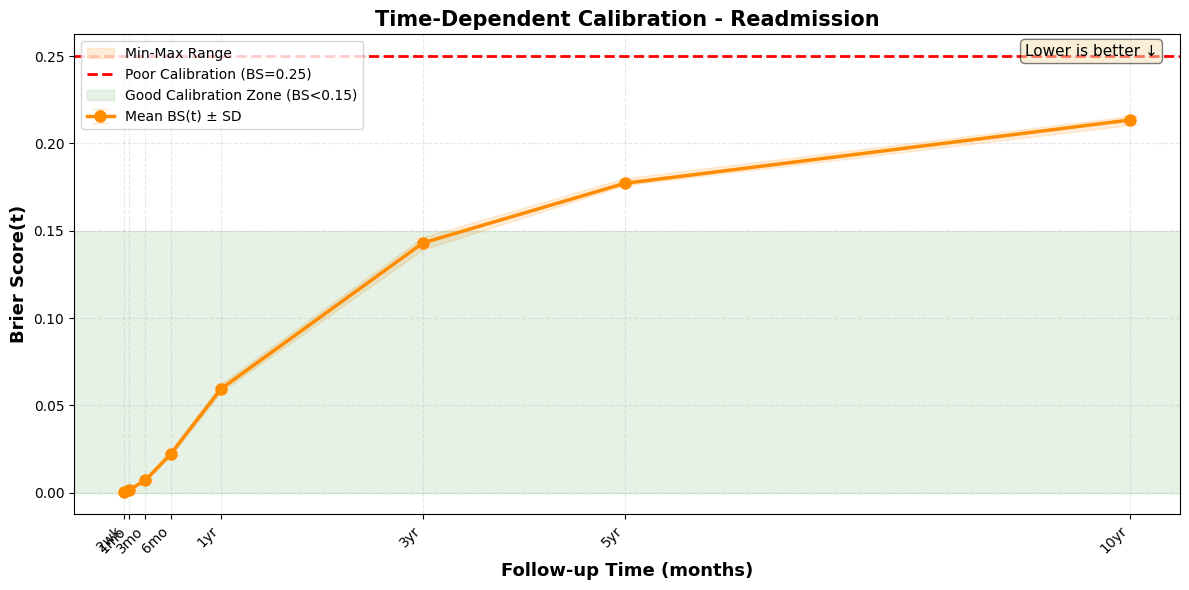

In [ ]:
from google.colab import data_table
data_table.enable_dataframe_formatter()

# ==================== USAGE EXAMPLE ====================
if __name__ == "__main__":
    # Define time grid
    times_eval_grid = np.array([
        0.5,   # 2 weeks
        1,     # 1 month
        3,     # 3 months
        6,     # 6 months
        12,    # 1 year
        36,    # 3 years
        60,    # 5 years
        120    # 10 years
    ])

    # Start timer
    start_time = time.time()

    # Run calibration analysis
    df_global_calib, df_time_calib, df_importance_calib = (
        permutation_importance_calibration_timespecific_cv_mi(
            X_list=imputations_list_jan26,
            y_surv_list=y_surv_readm_list_corrected,
            times_eval=times_eval_grid,
            alpha_idx=49,  # Use last alpha (least regularization)
            n_splits=5,
            n_repeats=50,
            random_state=2125,
            # Corrected parameters to avoid model collapse
            l1_ratio=0.1,              # More Ridge
            alpha_min_ratio=0.01,     # Allow smaller alphas
            n_alphas=50,
            max_iter=100000,
            n_jobs=-1
        )
    )

    # End timer
    end_time = time.time() # Print elapsed time in seconds
    elapsed = end_time - start_time
    print(f"Process completed in {elapsed/60:.2f} minutes")

    # Display results
    print("\n" + "="*80)
    print("DETAILED GLOBAL CALIBRATION METRICS")
    print("="*80)
    print(df_global_calib.T)

    print("\n" + "="*80)
    print("DETAILED TIME-SPECIFIC CALIBRATION")
    print("="*80)
    print(df_time_calib)

    print("\n" + "="*80)
    print("TOP 20 FEATURES (CALIBRATION IMPORTANCE)")
    print("="*80)
    # Apply a heat-map (YlOrRd = Yellow to Orange to Red)
    styled_calib = df_importance_calib.head(20).style \
        .background_gradient(subset=['mean_increase_ibs'], cmap='YlOrRd') \
        .format({'mean_increase_ibs': '{:.4f}', 'sd_increase_ibs': '{:.4f}'})

    display(styled_calib)

    # Visualize
    plot_time_dependent_calibration(df_time_calib, outcome_name="Readmission")

For death

In [ ]:
# Start timer
start_time = time.time()

df_death_calib, df_time_calib_death, df_importance_calib_death = (
    permutation_importance_calibration_timespecific_cv_mi(
        X_list=imputations_list_jan26,
        y_surv_list=y_surv_death_list,
        times_eval=times_eval_grid,
        alpha_idx=49,  # Use last alpha (least regularization)
        n_splits=10,
        n_repeats=50,
        random_state=2125,
        # Corrected parameters to avoid model collapse
        l1_ratio=0.1,              # More Ridge
        alpha_min_ratio=0.01,     # Allow smaller alphas
        n_alphas=50,
        max_iter=100000,
        n_jobs=-1
    )
)

# End timer
end_time = time.time() # Print elapsed time in seconds
elapsed = end_time - start_time
print(f"Process completed in {elapsed/60:.2f} minutes")

# Display results
print("\n" + "="*80)
print("DETAILED GLOBAL CALIBRATION METRICS")
print("="*80)
print(df_death_calib.T)

print("\n" + "="*80)
print("DETAILED TIME-SPECIFIC CALIBRATION")
print("="*80)
print(df_time_calib_death)

print("\n" + "="*80)
print("TOP 20 FEATURES (CALIBRATION IMPORTANCE)")
print("="*80)
# Apply a heat-map (YlOrRd = Yellow to Orange to Red)
styled_calib = df_importance_calib_death.head(20).style \
    .background_gradient(subset=['mean_increase_ibs'], cmap='YlOrRd') \
    .format({'mean_increase_ibs': '{:.4f}', 'sd_increase_ibs': '{:.4f}'})

display(styled_calib)

# Visualize
plot_time_dependent_calibration(df_time_calib_death, outcome_name="Mortality")

## Pruebas

In [ ]:
# Verificar:
print(f"N total: {len(y_surv_death_list[0])}")
print(f"N Events (deaths): {y_surv_death_list[0]['event'].sum()}")
print(f"Prevalence: {y_surv_death_list[0]['event'].mean():.3f}")
print(f"Positive times: {(y_surv_death_list[0]['time'] > 0).all()}")

# Esperado para mortalidad:
# - Eventos: 50-200 (3-5% de ~4000)
# - Prevalencia: 0.03-0.05
# - Todos los tiempos > 0

 ###     CoxPH w/o regularization w/ multiple imputation & CV

Útil para:
1. **Check whether the data have predictive signal**  
2. **Obtain interpretable coefficients (without shrinkage)**  
3. **Establish a baseline comparison with Coxnet**  

In [ ]:
#@title 🛠️ Unregularized CoxPH Analysis (Robust MI + CV) { display-mode: "form" }

import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.metrics import (
    concordance_index_ipcw,
    cumulative_dynamic_auc,
    brier_score,
    integrated_brier_score
)
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
from sksurv.util import Surv

def coxph_unregularized_cv_mi(
    X_list,
    y_surv_list,
    times_eval,
    n_splits=5,
    random_state=2125,
    n_jobs=-1,
    verbose=True
):
    """
    Unregularized CoxPH with Multiple Imputation and CV.

    Now uses robust mathematical calculation for Survival Function S(t|x)
    to avoid NaNs and improve speed during extrapolation.

    Parameters
    ----------
    X_list : list of pandas.DataFrame
        List of imputed datasets.
    y_surv_list : list of structured arrays
        List of outcomes Surv(event, time).
    times_eval : array-like
        Time points for evaluation.
    n_splits : int
        Number of CV folds.

    Returns
    -------
    results : dict
        Raw results.
    df_metrics : pandas.DataFrame
        Aggregated metrics.
    df_coefs : pandas.DataFrame
        Aggregated coefficients.
    """
    # --- Preparation ---
    feature_names = X_list[0].columns.tolist()
    n_features = len(feature_names)
    X_list_np = [X.values.astype(float) for X in X_list]
    n_imputations = len(X_list)
    n = X_list_np[0].shape[0]

    # Filter evaluation times
    max_time_data = np.max([y['time'].max() for y in y_surv_list])
    times_eval = np.array(times_eval)

    # We allow some extrapolation (e.g., 1.5x max time) because we use the robust
    # mathematical method now, but generally, we filter absurdly high values.
    times_eval = times_eval[times_eval <= max_time_data * 1.5]
    n_times = len(times_eval)

    # CV splits
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    cv_splits = list(kf.split(np.arange(n)))

    def format_time_label(months):
        if months < 1:
            return f"{int(months*4)}wk"
        elif months < 12:
            return f"{int(months)}mo"
        else:
            return f"{int(months/12)}yr"

    def compute_fold(d, fold_idx, train_idx, test_idx):
        """Compute metrics for a single fold using robust matrix math."""
        if verbose:
            print(f"  Imputation {d+1}/{n_imputations}, fold {fold_idx+1}/{n_splits}")

        X_imp = X_list_np[d]
        y_imp = y_surv_list[d]

        X_train = X_imp[train_idx]
        X_test = X_imp[test_idx]
        y_train = y_imp[train_idx]
        y_test = y_imp[test_idx]

        try:
            # Fit Unregularized CoxPH
            # ties="efron" is standard and generally accurate
            model = CoxPHSurvivalAnalysis(alpha=0.0, ties="efron", verbose=0)
            model.fit(X_train, y_train)

            # --- ROBUST MATHEMATICAL CALCULATION START ---

            # 1. Get Risk Scores (Linear Predictor: X * beta)
            # Shape: (n_test_samples,)
            risk_scores = model.predict(X_test)

            # 2. Get Cumulative Baseline Hazard H0(t)
            # cum_baseline_hazard_ is a StepFunction. It automatically extrapolates
            # (constant extension) for times beyond the last training event.
            H0_func = model.cum_baseline_hazard_
            H0_at_times = H0_func(times_eval) # Shape: (n_times,)

            # 3. Calculate Survival Probability Matrix Manually
            # Formula: S(t|x) = exp( -H0(t) * exp(risk_score) )
            # Broadcasting: (1, n_times) * (n_samples, 1) -> (n_samples, n_times)
            S_test = np.exp(-H0_at_times[None, :] * np.exp(risk_scores)[:, None])

            # --- ROBUST MATHEMATICAL CALCULATION END ---

            # 1. C-index
            try:
                c_index = concordance_index_ipcw(y_train, y_test, risk_scores)[0]
            except:
                c_index = np.nan

            # 2. Time-specific AUC
            try:
                auc_scores, mean_auc = cumulative_dynamic_auc(
                    y_train, y_test, risk_scores, times=times_eval
                )
            except:
                auc_scores = np.full(n_times, np.nan)

            # 3. Time-specific Brier Score (Vectorized)
            try:
                # Passing the full matrix S_test and array times_eval is faster/safer
                _, bs_scores = brier_score(y_train, y_test, S_test, times=times_eval)
            except:
                # Fallback if global call fails (rare with valid S_test)
                bs_scores = np.full(n_times, np.nan)

            # 4. Integrated Brier Score
            try:
                ibs = integrated_brier_score(y_train, y_test, S_test, times=times_eval)
            except:
                ibs = np.nan

            # 5. Extract Coefficients
            coefs = model.coef_.copy()

            return {
                'success': True,
                'c_index': c_index,
                'auc_scores': auc_scores,
                'bs_scores': bs_scores,
                'ibs': ibs,
                'coefs': coefs,
                'n_coefs_nonzero': np.sum(coefs != 0),
                'max_abs_coef': np.max(np.abs(coefs))
            }

        except Exception as e:
            if verbose:
                print(f"    ERROR in fold: {str(e)}")
            return {
                'success': False,
                'c_index': np.nan,
                'auc_scores': np.full(n_times, np.nan),
                'bs_scores': np.full(n_times, np.nan),
                'ibs': np.nan,
                'coefs': np.full(n_features, np.nan),
                'n_coefs_nonzero': 0,
                'max_abs_coef': 0.0
            }

    # ==================== PARALLEL EXECUTION ====================
    if verbose:
        print(f"\n{'='*80}")
        print(f"CoxPH UNREGULARIZED (ROBUST) - MULTIPLE IMPUTATION + CV")
        print(f"{'='*80}")
        print(f"Imputations: {n_imputations}, CV folds: {n_splits}")
        print(f"Features: {n_features}, Samples: {n}")
        print(f"Time points: {n_times}")
        print(f"{'='*80}\n")

    results = Parallel(n_jobs=n_jobs, backend='loky', verbose=5 if verbose else 0)(
        delayed(compute_fold)(d, fold_idx, train_idx, test_idx)
        for d in range(n_imputations)
        for fold_idx, (train_idx, test_idx) in enumerate(cv_splits)
    )

    # Filter successful results
    successful_results = [r for r in results if r['success']]
    n_successful = len(successful_results)

    if n_successful == 0:
        raise ValueError("All folds failed. Check data consistency or hyperparameters.")

    # ==================== AGGREGATE METRICS ====================

    # C-index aggregation
    c_indices = [r['c_index'] for r in successful_results]
    c_mean = np.nanmean(c_indices)
    c_sd = np.nanstd(c_indices, ddof=1)

    # AUC aggregation
    all_aucs = np.array([r['auc_scores'] for r in successful_results])
    auc_mean_global = np.nanmean(all_aucs)
    auc_sd_global = np.nanstd(all_aucs, ddof=1)

    # Brier Score aggregation
    all_bs = np.array([r['bs_scores'] for r in successful_results])
    bs_mean_global = np.nanmean(all_bs)
    bs_sd_global = np.nanstd(all_bs, ddof=1)

    # IBS aggregation
    ibs_list = [r['ibs'] for r in successful_results]
    ibs_mean = np.nanmean(ibs_list)
    ibs_sd = np.nanstd(ibs_list, ddof=1)

    # Coefficients aggregation
    all_coefs = np.array([r['coefs'] for r in successful_results])
    coef_mean = np.nanmean(all_coefs, axis=0)
    coef_sd = np.nanstd(all_coefs, axis=0, ddof=1)
    coef_min = np.nanmin(all_coefs, axis=0)
    coef_max = np.nanmax(all_coefs, axis=0)

    # ==================== DATAFRAMES ====================

    # 1. Time-specific metrics
    time_rows = []
    for i, t in enumerate(times_eval):
        auc_at_t = all_aucs[:, i]
        bs_at_t = all_bs[:, i]
        time_rows.append({
            'time_months': t,
            'time_label': format_time_label(t),
            'auc_mean': np.nanmean(auc_at_t),
            'auc_sd': np.nanstd(auc_at_t, ddof=1),
            'bs_mean': np.nanmean(bs_at_t),
            'bs_sd': np.nanstd(bs_at_t, ddof=1),
            'n_evals': np.sum(~np.isnan(auc_at_t))
        })
    df_time = pd.DataFrame(time_rows)

    # 2. Coefficient stats
    df_coefs = pd.DataFrame({
        'feature': feature_names,
        'coef_mean': coef_mean,
        'coef_sd': coef_sd,
        'coef_min': coef_min,
        'coef_max': coef_max,
        'abs_coef_mean': np.abs(coef_mean),
        'is_stable': (np.sign(coef_min) == np.sign(coef_max)) & (coef_mean != 0)
    })
    df_coefs = df_coefs.sort_values('abs_coef_mean', ascending=False).reset_index(drop=True)

    # 3. Global summary
    df_global = pd.DataFrame([{
        'c_index_mean': c_mean,
        'c_index_sd': c_sd,
        'auc_mean_global': auc_mean_global,
        'ibs_mean': ibs_mean,
        'n_successful_folds': n_successful
    }])

    # Combine for display
    df_metrics = pd.concat([
        df_global.T.rename(columns={0: 'value'}).assign(category='global'),
        df_time.set_index('time_label').stack().reset_index().rename(
            columns={'level_1': 'metric', 0: 'value'}
        ).assign(category='time_specific')
    ], ignore_index=True)

    if verbose:
        print(f"\n{'='*80}")
        print(f"RESULTS SUMMARY")
        print(f"{'='*80}")
        print(f"Global C-index: {c_mean:.4f} ± {c_sd:.4f}")
        print(f"Aggregated AUC: {auc_mean_global:.4f} ± {auc_sd_global:.4f}")
        print(f"Global IBS:     {ibs_mean:.4f} ± {ibs_sd:.4f}")
        print(f"Aggregated BS: {bs_mean_global:.4f} ± {bs_sd_global:.4f}")
        print(f"\n>>> TIME-SPECIFIC PERFORMANCE <<<")
        print(df_time[['time_label', 'auc_mean', 'auc_sd', 'bs_mean', 'bs_sd', 'n_evals']].to_string(index=False))
        print(f"\n>>> TOP 5 COEFFICIENTS <<<")
        print(df_coefs[['feature', 'coef_mean', 'coef_sd', 'is_stable']].head(5).to_string(index=False))
        print(f"{'='*80}\n")

    return {
        'c_indices': c_indices,
        'auc_scores_all': all_aucs,
        'bs_scores_all': all_bs,
        'ibs_list': ibs_list,
        'coefs_all': all_coefs,
    }, df_metrics, df_coefs, df_time


In [ ]:
#@title Function test { display-mode: "form" }
#@markdown To test the function. Deactivated block
run_diagnostic_cox = True #@param {type:"boolean"}

if run_diagnostic_cox:
  # ==============================================================================
  # TEST BLOCK: RUN THIS TO VERIFY THE FUNCTION
  # ==============================================================================
  if __name__ == "__main__":
      print("🚀 STARTING TEST WITH SYNTHETIC DATA...\n")

      # 1. Generate Dummy Data
      np.random.seed(42)
      n_samples = 200
      n_feats = 10

      # Features
      X = np.random.randn(n_samples, n_feats)
      columns = [f"feat_{i}" for i in range(n_feats)]
      df_X = pd.DataFrame(X, columns=columns)

      # Outcome (Time + Event)
      # We create a simple relationship: risk depends on feat_0 and feat_1
      risk = X[:, 0] + X[:, 1]
      T = np.random.exponential(10 * np.exp(-risk)) # Time
      E = np.random.binomial(1, 0.7, size=n_samples).astype(bool) # Event (30% censored)

      # Create structured array for sksurv
      y = Surv.from_arrays(event=E, time=T)

      # 2. Simulate Multiple Imputation (3 copies of X with tiny noise)
      X_list = [
          df_X.copy(),
          df_X + np.random.normal(0, 0.01, size=df_X.shape),
          df_X + np.random.normal(0, 0.01, size=df_X.shape)
      ]
      y_list = [y, y, y] # Same outcome for all

      # 3. Define Times
      # We include a time point strictly larger than max(T) to test extrapolation
      times_eval = [5, 10, 50, 100]
      print(f"Max observed time in data: {T.max():.2f}")
      print(f"Evaluating at: {times_eval}")

      # 4. Run Function
      try:
          results, df_metrics, df_coefs, df_time = coxph_unregularized_cv_mi(
              X_list=X_list,
              y_surv_list=y_list,
              times_eval=times_eval,
              n_splits=3,      # Small split for testing
              n_jobs=1,        # No parallel for simple test to see prints clearly
              verbose=True
          )
          print("\n✅ TEST PASSED SUCCESSFULLY!")

      except Exception as e:
          print(f"\n❌ TEST FAILED: {e}")
          import traceback
          traceback.print_exc()

In [ ]:
#@title 📊 Visualization Suite: CoxPH & Model Comparison { display-mode: "form" }
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.metrics import (
    concordance_index_ipcw,
    cumulative_dynamic_auc,
    brier_score,
    integrated_brier_score
)
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
import seaborn as sns
# ==================== VISUALIZATION FUNCTIONS ====================

def plot_coxph_coefficients(df_coefs, top_n=20, figsize=(12, 8)):
    """
    Visualizar coeficientes del CoxPH con intervalos de confianza.
    """
    df_plot = df_coefs.head(top_n).copy()

    fig, ax = plt.subplots(figsize=figsize)

    # Color por signo
    colors = ['red' if c < 0 else 'steelblue' for c in df_plot['coef_mean']]

    # Bar plot con error bars
    y_pos = np.arange(len(df_plot))
    ax.barh(y_pos, df_plot['coef_mean'], xerr=df_plot['coef_sd'],
            color=colors, alpha=0.7, capsize=5)

    # Añadir línea en x=0
    ax.axvline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.5)

    # Labels
    ax.set_yticks(y_pos)
    ax.set_yticklabels(df_plot['feature'], fontsize=10)
    ax.set_xlabel('Coefficient (Mean ± SD)', fontsize=12, fontweight='bold')
    ax.set_title(f'Top {top_n} CoxPH Coefficients (Unregularized)',
                 fontsize=14, fontweight='bold')

    # Legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='steelblue', alpha=0.7, label='Hazard ↑ (positive)'),
        Patch(facecolor='red', alpha=0.7, label='Hazard ↓ (negative)')
    ]
    ax.legend(handles=legend_elements, loc='lower right')

    # Grid
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.invert_yaxis()

    plt.tight_layout()
    plt.show()


def plot_coefficient_stability(df_coefs, top_n=20, figsize=(14, 8)):
    """
    Visualizar estabilidad de coeficientes (min/max range).
    """
    df_plot = df_coefs.head(top_n).copy()

    fig, ax = plt.subplots(figsize=figsize)

    y_pos = np.arange(len(df_plot))

    # Plot mean with range
    for i, row in df_plot.iterrows():
        # Range bar
        ax.plot([row['coef_min'], row['coef_max']], [i, i],
                color='lightgray', linewidth=6, alpha=0.5, zorder=1)

        # Mean point
        color = 'green' if row['is_stable'] else 'orange'
        marker = 'o' if row['is_stable'] else 'x'
        ax.scatter(row['coef_mean'], i, color=color, s=100, marker=marker,
                  zorder=3, edgecolor='black', linewidth=1.5)

    # Zero line
    ax.axvline(0, color='red', linestyle='--', linewidth=2, alpha=0.7)

    # Labels
    ax.set_yticks(y_pos)
    ax.set_yticklabels(df_plot['feature'], fontsize=10)
    ax.set_xlabel('Coefficient Value', fontsize=12, fontweight='bold')
    ax.set_title(f'Coefficient Stability Across CV Folds (Top {top_n})',
                 fontsize=14, fontweight='bold')

    # Legend
    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='green',
               markersize=10, markeredgecolor='black', label='Stable (same sign)'),
        Line2D([0], [0], marker='x', color='w', markerfacecolor='orange',
               markersize=10, markeredgewidth=2, label='Unstable (sign flips)'),
        Patch(facecolor='lightgray', alpha=0.5, label='Min-Max range')
    ]
    ax.legend(handles=legend_elements, loc='lower right')

    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.invert_yaxis()

    plt.tight_layout()
    plt.show()


def compare_coxph_vs_coxnet(df_coefs_coxph, df_coefs_coxnet, top_n=15):
    """
    Comparar coeficientes CoxPH vs Coxnet lado a lado.
    """
    # Merge por feature
    df_compare = pd.merge(
        df_coefs_coxph[['feature', 'coef_mean']].rename(columns={'coef_mean': 'coxph'}),
        df_coefs_coxnet[['feature', 'coef_mean']].rename(columns={'coef_mean': 'coxnet'}),
        on='feature',
        how='outer'
    ).fillna(0)

    # Ordenar por CoxPH
    df_compare['abs_coxph'] = np.abs(df_compare['coxph'])
    df_compare = df_compare.sort_values('abs_coxph', ascending=False).head(top_n)

    # Plot
    fig, ax = plt.subplots(figsize=(14, 8))

    x = np.arange(len(df_compare))
    width = 0.35

    ax.bar(x - width/2, df_compare['coxph'], width, label='CoxPH (unregularized)',
           color='steelblue', alpha=0.8)
    ax.bar(x + width/2, df_compare['coxnet'], width, label='Coxnet (regularized)',
           color='darkorange', alpha=0.8)

    ax.set_ylabel('Coefficient', fontsize=12, fontweight='bold')
    ax.set_title('Coefficient Comparison: CoxPH vs Coxnet', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(df_compare['feature'], rotation=45, ha='right', fontsize=9)
    ax.legend()
    ax.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.5)
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

    return df_compare


🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬
DIAGNOSTIC TEST: CoxPH WITHOUT REGULARIZATION
🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬

>>> OUTCOME: READMISSION <<<


CoxPH UNREGULARIZED (ROBUST) - MULTIPLE IMPUTATION + CV
Imputations: 5, CV folds: 5
Features: 56, Samples: 88504
Time points: 8



[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:   19.2s
[Parallel(n_jobs=-1)]: Done  16 out of  25 | elapsed:   38.5s remaining:   21.7s
[Parallel(n_jobs=-1)]: Done  22 out of  25 | elapsed:   57.0s remaining:    7.8s
[Parallel(n_jobs=-1)]: Done  25 out of  25 | elapsed:  1.1min finished



RESULTS SUMMARY
Global C-index: 0.6094 ± 0.0055
Aggregated AUC: 0.6710 ± 0.0751
Global IBS:     0.1528 ± 0.0014
Aggregated BS: 0.0778 ± 0.0816

>>> TIME-SPECIFIC PERFORMANCE <<<
time_label  auc_mean   auc_sd  bs_mean    bs_sd  n_evals
       2wk  0.704715 0.075706 0.000441 0.000156       25
       1mo  0.756759 0.056266 0.001377 0.000368       25
       3mo  0.729683 0.032692 0.007075 0.000317       25
       6mo  0.711202 0.007702 0.021945 0.001059       25
       1yr  0.681898 0.006577 0.058914 0.001652       25
       3yr  0.631991 0.003763 0.141276 0.002670       25
       5yr  0.604117 0.006324 0.175851 0.001442       25
      10yr  0.547835 0.017373 0.215881 0.002436       25

>>> TOP 5 COEFFICIENTS <<<
             feature  coef_mean  coef_sd  is_stable
    tr_outcome_other  -1.405156 0.201407       True
 plan_type_corr_m_pr   0.606533 0.029909       True
           porc_pobr   0.547964 0.030677       True
           ethnicity   0.516567 0.020128       True
plan_type_corr_pg_pr

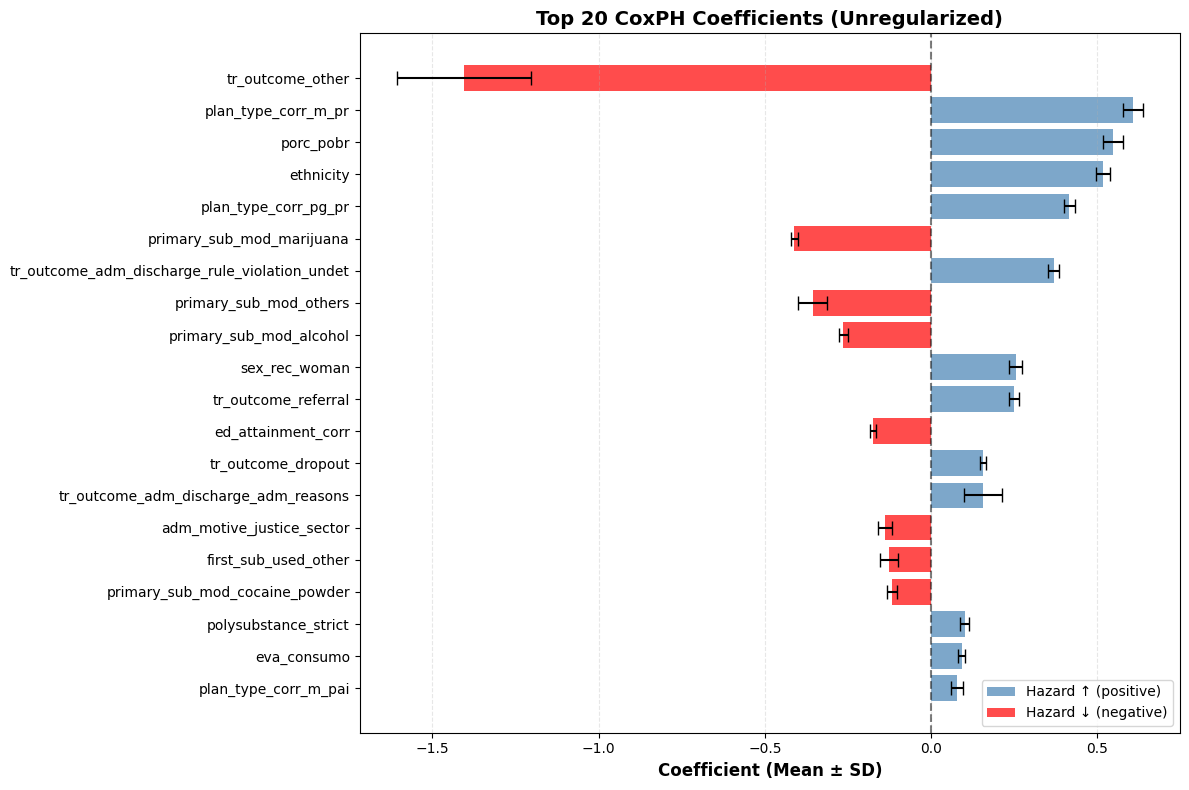

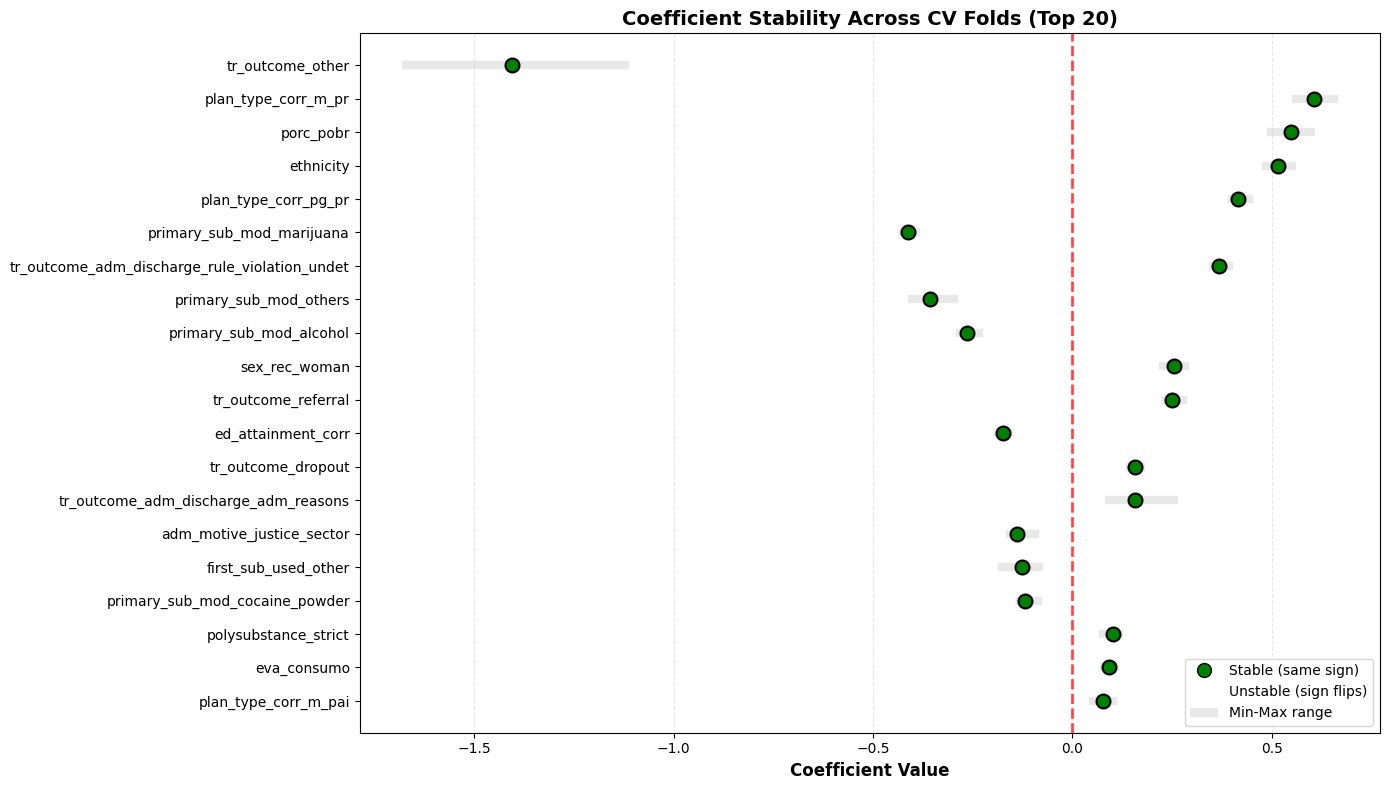

In [ ]:
# ==================== USAGE EXAMPLE ====================
if __name__ == "__main__":

    # Define time grid
    times_eval_grid = np.array([0.5, 1, 3, 6, 12, 36, 60, 120])

    print("\n" + "🔬"*40)
    print("DIAGNOSTIC TEST: CoxPH WITHOUT REGULARIZATION")
    print("🔬"*40)

# ==================== READMISSION ====================
print("\n>>> OUTCOME: READMISSION <<<\n")
# Start timer
start_time = time.time()

results_coxph_readm, df_metrics_readm, df_coefs_readm, df_time_readm = (
    coxph_unregularized_cv_mi(
        X_list=imputations_list_jan26,
        y_surv_list=y_surv_readm_list_corrected,
        times_eval=times_eval_grid,
        n_splits=5,
        random_state=2125,
        n_jobs=-1,
        verbose=True
    )
)
# End timer
end_time = time.time() # Print elapsed time in seconds
elapsed = end_time - start_time
print(f"Process completed in {elapsed/60:.2f} minutes")

# Visualize coefficients
plot_coxph_coefficients(df_coefs_readm, top_n=20)
plot_coefficient_stability(df_coefs_readm, top_n=20)


In [ ]:
#@title 📁 Export Results to Excel { display-mode: "form" }
#@markdown Click the play button to bundle all results into a single .xlsx file and download it.
save_readm_unreg = True #@param {type:"boolean"}

from google.colab import files
import pandas as pd
from datetime import datetime


def export_survival_results():
    # 1. Create a timestamp for the filename
    timestamp = datetime.now().strftime("%Y%m%d_%H%M")
    filename = f"CoxPH_Readmission_Results_{timestamp}.xlsx"

    # 2. Use ExcelWriter to save multiple DataFrames as sheets
    with pd.ExcelWriter(filename, engine='xlsxwriter') as writer:
        # Global metrics (Summary)
        df_metrics_readm.to_excel(writer, sheet_name='Global_Metrics', index=False)

        # Coefficients
        df_coefs_readm.to_excel(writer, sheet_name='Coefficients', index=False)

        # Performance over time (AUC/Brier)
        df_time_readm.to_excel(writer, sheet_name='Time_Metrics', index=False)

    print(f"✅ Excel file '{filename}' created.")

    # 3. Trigger browser download
    files.download(filename)

# Run the export
if save_readm_unreg:
  try:
      export_survival_results()
  except NameError:
      print("❌ Error: Result variables not found. Please run the CoxPH analysis first.")

In [ ]:
#@title 📸 Export graphs as ZIP { display-mode: "form" }
#@markdown  Click the play button to bundle all plots into a single .zip file and download it.
save_plots_readm = True #@param {type:"boolean"}

from google.colab import files
import matplotlib.pyplot as plt
import os
import shutil # Para crear archivos ZIP
from datetime import datetime

def export_all_plots(df_coefs, plot_prefix="CoxPH_Readm", top_n=20):
    """
    Genera y guarda los gráficos de coeficientes y estabilidad,
    luego los comprime en un archivo ZIP.
    """
    # Create a temporary directory to save plots
    plot_dir = f"temp_plots_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
    os.makedirs(plot_dir, exist_ok=True)

    plot_paths = []

    # --- Plot 1: Coeficientes ---
    try:
        fig1, ax1 = plt.subplots(figsize=(12, 8))
        df_plot = df_coefs.head(top_n).copy()
        colors = ['red' if c < 0 else 'steelblue' for c in df_plot['coef_mean']]
        y_pos = np.arange(len(df_plot))
        ax1.barh(y_pos, df_plot['coef_mean'], xerr=df_plot['coef_sd'],
                 color=colors, alpha=0.7, capsize=5)
        ax1.axvline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.5)
        ax1.set_yticks(y_pos)
        ax1.set_yticklabels(df_plot['feature'], fontsize=10)
        ax1.set_xlabel('Coefficient (Mean ± SD)', fontsize=12, fontweight='bold')
        ax1.set_title(f'Top {top_n} CoxPH Coefficients (Unregularized)',
                      fontsize=14, fontweight='bold')
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor='steelblue', alpha=0.7, label='Hazard ↑ (positive)'),
            Patch(facecolor='red', alpha=0.7, label='Hazard ↓ (negative)')
        ]
        ax1.legend(handles=legend_elements, loc='lower right')
        ax1.grid(axis='x', alpha=0.3, linestyle='--')
        ax1.invert_yaxis()
        plt.tight_layout()
        plot_path_coefs = os.path.join(plot_dir, f"{plot_prefix}_Coefficients.pdf")
        plt.savefig(plot_path_coefs, bbox_inches='tight', dpi=300)
        plot_paths.append(plot_path_coefs)
        plt.close(fig1) # Close figure to free memory
    except Exception as e:
        print(f"⚠️ Error saving Coefficients plot: {e}")

    # --- Plot 2: Estabilidad de Coeficientes ---
    try:
        fig2, ax2 = plt.subplots(figsize=(14, 8))
        df_plot = df_coefs.head(top_n).copy()
        y_pos = np.arange(len(df_plot))
        for i, row in df_plot.iterrows():
            ax2.plot([row['coef_min'], row['coef_max']], [i, i],
                     color='lightgray', linewidth=6, alpha=0.5, zorder=1)
            color = 'green' if row['is_stable'] else 'orange'
            marker = 'o' if row['is_stable'] else 'x'
            ax2.scatter(row['coef_mean'], i, color=color, s=100, marker=marker,
                        zorder=3, edgecolor='black', linewidth=1.5)
        ax2.axvline(0, color='red', linestyle='--', linewidth=2, alpha=0.7)
        ax2.set_yticks(y_pos)
        ax2.set_yticklabels(df_plot['feature'], fontsize=10)
        ax2.set_xlabel('Coefficient Value', fontsize=12, fontweight='bold')
        ax2.set_title(f'Coefficient Stability Across CV Folds (Top {top_n})',
                      fontsize=14, fontweight='bold')
        from matplotlib.patches import Patch
        from matplotlib.lines import Line2D
        legend_elements = [
            Line2D([0], [0], marker='o', color='w', markerfacecolor='green',
                   markersize=10, markeredgecolor='black', label='Stable (same sign)'),
            Line2D([0], [0], marker='x', color='w', markerfacecolor='orange',
                   markersize=10, markeredgewidth=2, label='Unstable (sign flips)'),
            Patch(facecolor='lightgray', alpha=0.5, label='Min-Max range')
        ]
        ax2.legend(handles=legend_elements, loc='lower right')
        ax2.grid(axis='x', alpha=0.3, linestyle='--')
        ax2.invert_yaxis()
        plt.tight_layout()
        plot_path_stability = os.path.join(plot_dir, f"{plot_prefix}_Stability.pdf")
        plt.savefig(plot_path_stability, bbox_inches='tight', dpi=300)
        plot_paths.append(plot_path_stability)
        plt.close(fig2) # Close figure to free memory
    except Exception as e:
        print(f"⚠️ Error saving Stability plot: {e}")

    # --- Comprimir en ZIP ---
    if plot_paths:
        zip_filename = f"{plot_prefix}_Plots_{datetime.now().strftime('%Y%m%d_%H%M')}.zip"
        shutil.make_archive(zip_filename.replace('.zip', ''), 'zip', plot_dir)
        print(f"✅ All plots saved to '{zip_filename}'")
        files.download(zip_filename)
    else:
        print("⛔ No plots were successfully generated to zip.")

    # Clean up temporary directory
    shutil.rmtree(plot_dir)


# --- Lógica de Ejecución con Checkbox ---
if save_plots_readm:
    try:
        # Aquí pasas el DataFrame de coeficientes real
        export_all_plots(df_coefs_readm)
    except NameError:
        print("❌ Error: 'df_coefs_readm' not found. Please run the CoxPH analysis first.")
    except Exception as e:
        print(f"An unexpected error occurred during plot export: {e}")
else:
    print("ℹ️ Plot download checkbox is 'False'. Mark it and click Play to download plots.")

For mortality

In [ ]:
# ==================== MORTALITY ====================
print("\n>>> OUTCOME: MORTALITY <<<\n")
# Start timer
start_time = time.time()

results_coxph_death, df_metrics_death, df_coefs_death, df_time_death = (
    coxph_unregularized_cv_mi(
        X_list=imputations_list_jan26,
        y_surv_list=y_surv_death_list,  # ← CAMBIAR al outcome correcto
        times_eval=times_eval_grid,
        n_splits=5,
        random_state=2125,
        n_jobs=-1,
        verbose=True
    )
)
# End timer
end_time = time.time() # Print elapsed time in seconds
elapsed = end_time - start_time
print(f"Process completed in {elapsed/60:.2f} minutes")

# Visualize coefficients
plot_coxph_coefficients(df_coefs_death, top_n=20)
plot_coefficient_stability(df_coefs_death, top_n=20)

print("\n✅ CoxPH analysis complete. Coefficients saved.")

# ==================== INTERPRETATION GUIDE ====================
print("\n" + "="*80)
print("INTERPRETATION GUIDE")
print("="*80)
print("""
C-index Interpretation:
- < 0.52  → No discriminative power (baseline model)
- 0.52-0.60 → Weak discrimination (marginal signal)
- 0.60-0.70 → Moderate discrimination (acceptable)
- > 0.70  → Good discrimination (strong signal)

Coefficient Interpretation:
- Positive coef → ↑ Hazard (worse prognosis)
- Negative coef → ↓ Hazard (better prognosis)
- HR = exp(coef) → Hazard Ratio per 1-unit increase

Stability:
- is_stable = True → Coefficient sign consistent across folds
- is_stable = False → Unstable effect (multicollinearity?)

Next Steps:
1. If C-index > 0.55 → Data has signal, use Coxnet with less regularization
2. If C-index ≈ 0.50 → Problem with data/outcome, investigate further
3. Compare coefs with Coxnet to see shrinkage effect
""")
print("="*80)

In [ ]:
#@title 📁 Export Results to Excel { display-mode: "form" }
#@markdown Click the play button to bundle all results into a single .xlsx file and download it.
save_death_unreg = True #@param {type:"boolean"}

from google.colab import files
import pandas as pd
from datetime import datetime

def export_survival_results():
    # 1. Create a timestamp for the filename
    timestamp = datetime.now().strftime("%Y%m%d_%H%M")
    filename = f"CoxPH_Death_Results_{timestamp}.xlsx"

    # 2. Use ExcelWriter to save multiple DataFrames as sheets
    with pd.ExcelWriter(filename, engine='xlsxwriter') as writer:
        # Global metrics (Summary)
        df_metrics_death.to_excel(writer, sheet_name='Global_Metrics', index=False)

        # Coefficients
        df_coefs_death.to_excel(writer, sheet_name='Coefficients', index=False)

        # Performance over time (AUC/Brier)
        df_time_death.to_excel(writer, sheet_name='Time_Metrics', index=False)

    print(f"✅ Excel file '{filename}' created.")

    # 3. Trigger browser download
    files.download(filename)

# Run the export
if save_death_unreg:
  try:
      export_survival_results()
  except NameError:
      print("❌ Error: Result variables not found. Please run the CoxPH analysis first.")

In [ ]:
#@title 📸 Export graphs as ZIP { display-mode: "form" }
#@markdown  Click the play button to bundle all plots into a single .zip file and download it.
save_plots_death = True #@param {type:"boolean"}

from google.colab import files
import matplotlib.pyplot as plt
import os
import shutil # Para crear archivos ZIP
from datetime import datetime

def export_all_plots(df_coefs, plot_prefix="CoxPH_Death", top_n=20):
    """
    Genera y guarda los gráficos de coeficientes y estabilidad,
    luego los comprime en un archivo ZIP.
    """
    # Create a temporary directory to save plots
    plot_dir = f"temp_plots_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
    os.makedirs(plot_dir, exist_ok=True)

    plot_paths = []

    # --- Plot 1: Coeficientes ---
    try:
        fig1, ax1 = plt.subplots(figsize=(12, 8))
        df_plot = df_coefs.head(top_n).copy()
        colors = ['red' if c < 0 else 'steelblue' for c in df_plot['coef_mean']]
        y_pos = np.arange(len(df_plot))
        ax1.barh(y_pos, df_plot['coef_mean'], xerr=df_plot['coef_sd'],
                 color=colors, alpha=0.7, capsize=5)
        ax1.axvline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.5)
        ax1.set_yticks(y_pos)
        ax1.set_yticklabels(df_plot['feature'], fontsize=10)
        ax1.set_xlabel('Coefficient (Mean ± SD)', fontsize=12, fontweight='bold')
        ax1.set_title(f'Top {top_n} CoxPH Coefficients (Unregularized)',
                      fontsize=14, fontweight='bold')
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor='steelblue', alpha=0.7, label='Hazard ↑ (positive)'),
            Patch(facecolor='red', alpha=0.7, label='Hazard ↓ (negative)')
        ]
        ax1.legend(handles=legend_elements, loc='lower right')
        ax1.grid(axis='x', alpha=0.3, linestyle='--')
        ax1.invert_yaxis()
        plt.tight_layout()
        plot_path_coefs = os.path.join(plot_dir, f"{plot_prefix}_Coefficients.pdf")
        plt.savefig(plot_path_coefs, bbox_inches='tight', dpi=300)
        plot_paths.append(plot_path_coefs)
        plt.close(fig1) # Close figure to free memory
    except Exception as e:
        print(f"⚠️ Error saving Coefficients plot: {e}")

    # --- Plot 2: Estabilidad de Coeficientes ---
    try:
        fig2, ax2 = plt.subplots(figsize=(14, 8))
        df_plot = df_coefs.head(top_n).copy()
        y_pos = np.arange(len(df_plot))
        for i, row in df_plot.iterrows():
            ax2.plot([row['coef_min'], row['coef_max']], [i, i],
                     color='lightgray', linewidth=6, alpha=0.5, zorder=1)
            color = 'green' if row['is_stable'] else 'orange'
            marker = 'o' if row['is_stable'] else 'x'
            ax2.scatter(row['coef_mean'], i, color=color, s=100, marker=marker,
                        zorder=3, edgecolor='black', linewidth=1.5)
        ax2.axvline(0, color='red', linestyle='--', linewidth=2, alpha=0.7)
        ax2.set_yticks(y_pos)
        ax2.set_yticklabels(df_plot['feature'], fontsize=10)
        ax2.set_xlabel('Coefficient Value', fontsize=12, fontweight='bold')
        ax2.set_title(f'Coefficient Stability Across CV Folds (Top {top_n})',
                      fontsize=14, fontweight='bold')
        from matplotlib.patches import Patch
        from matplotlib.lines import Line2D
        legend_elements = [
            Line2D([0], [0], marker='o', color='w', markerfacecolor='green',
                   markersize=10, markeredgecolor='black', label='Stable (same sign)'),
            Line2D([0], [0], marker='x', color='w', markerfacecolor='orange',
                   markersize=10, markeredgewidth=2, label='Unstable (sign flips)'),
            Patch(facecolor='lightgray', alpha=0.5, label='Min-Max range')
        ]
        ax2.legend(handles=legend_elements, loc='lower right')
        ax2.grid(axis='x', alpha=0.3, linestyle='--')
        ax2.invert_yaxis()
        plt.tight_layout()
        plot_path_stability = os.path.join(plot_dir, f"{plot_prefix}_Stability.pdf")
        plt.savefig(plot_path_stability, bbox_inches='tight', dpi=300)
        plot_paths.append(plot_path_stability)
        plt.close(fig2) # Close figure to free memory
    except Exception as e:
        print(f"⚠️ Error saving Stability plot: {e}")

    # --- Comprimir en ZIP ---
    if plot_paths:
        zip_filename = f"{plot_prefix}_Plots_{datetime.now().strftime('%Y%m%d_%H%M')}.zip"
        shutil.make_archive(zip_filename.replace('.zip', ''), 'zip', plot_dir)
        print(f"✅ All plots saved to '{zip_filename}'")
        files.download(zip_filename)
    else:
        print("⛔ No plots were successfully generated to zip.")

    # Clean up temporary directory
    shutil.rmtree(plot_dir)

# --- Lógica de Ejecución con Checkbox ---
if save_plots_death:
    try:
        # Aquí pasas el DataFrame de coeficientes real
        export_all_plots(df_coefs_death)
    except NameError:
        print("❌ Error: 'df_coefs_death' not found. Please run the CoxPH analysis first.")
    except Exception as e:
        print(f"An unexpected error occurred during plot export: {e}")
else:
    print("ℹ️ Plot download checkbox is 'False'. Mark it and click Play to download plots.")

### Compare to KM

#### Readmission

In [ ]:
from sksurv.metrics import integrated_brier_score
from sksurv.linear_model import CoxPHSurvivalAnalysis # Or just use KM directly
from sksurv.nonparametric import kaplan_meier_estimator
import numpy as np

# 1. Calculate the Kaplan-Meier Estimate (The "Null" Prediction)
# We need to create a probability matrix where every row is the KM curve
km_times, km_probs = kaplan_meier_estimator(y_surv_readm["event"], y_surv_readm["time"])

# Interpolate KM probabilities to match your 'times_eval'
# This creates a "Null Prediction" where every patient gets the exact same probability
null_probs = np.interp(times_eval_readm, km_times, km_probs)
null_preds = np.tile(null_probs, (len(y_surv_readm), 1))

# 2. Calculate IBS for the Null Model
null_ibs = integrated_brier_score(y_surv_readm, y_surv_readm, null_preds, times_eval_readm)

print(f"Model IBS: 0.1427")
print(f"Null (KM) IBS: {null_ibs:.4f}")

if 0.1427 < null_ibs - 0.005:
    print("VERDICT: The model has predictive power.")
else:
    print("VERDICT: The model is NOT performing better than random guessing (Kaplan-Meier).")

Model IBS: 0.1427
Null (KM) IBS: 0.1351
VERDICT: The model is NOT performing better than random guessing (Kaplan-Meier).


#### Death

In [12]:
from sksurv.metrics import integrated_brier_score
from sksurv.nonparametric import kaplan_meier_estimator
import numpy as np

# 1. Calculate the Kaplan-Meier Estimate (The "Average" Prediction)
km_times, km_probs = kaplan_meier_estimator(y_surv_death["event"], y_surv_death["time"])

# 2. Interpolate KM probabilities to match your evaluation times
# Note: Ensure 'times_eval_death' is defined in your environment
null_probs = np.interp(times_eval_death, km_times, km_probs)

# 3. Create the "Null Prediction" matrix (Same prediction for everyone)
null_preds = np.tile(null_probs, (len(y_surv_death), 1))

# 4. Calculate IBS for the Null Model
null_ibs_death = integrated_brier_score(y_surv_death, y_surv_death, null_preds, times_eval_death)

print(f"Model IBS:  0.0351") # From your logs
print(f"Null IBS:   {null_ibs_death:.4f}")

diff = 0.0351 - null_ibs_death

if abs(diff) < 0.001:
    print("\nCONCLUSION: The model is effectively ignoring all predictors.")
    print("It provides no value over a simple population average.")
else:
    print(f"\nCONCLUSION: There is a tiny difference ({diff:.5f}), but likely not clinically relevant.")

Model IBS:  0.0351
Null IBS:   0.0335

CONCLUSION: There is a tiny difference (0.00162), but likely not clinically relevant.


In [ ]:
#summary = df.groupby('group').describe()